# **02. bivariate & Correaltion Analysis**

This notebook is a continuation of the __data_cleaning_eda.ipynb__ notebook and builds upon the cleaned dataset to perform bivariate and correlation analyses.
##### **Description :** Examines relationships between predictor variables and the target variable, conducts correlation analysis, performs statistical tests where appropriate, visualizes feature associations using heatmaps and other plots, and identifies important variables for predictive modeling.

#### __Key Analysis Questions__

**Overall Campaign Performance**  
* What is the total conversion rate across all campaigns?

**Demographic Insights**  
* Which age group shows the strongest response?    
* Which job category delivers the highest conversion?
* What is the subscription breakdown by education level?

**Timing Effectiveness**  
* Which month achieves peak campaign performance?

**Financial/Behaviour Insights**  
* How do housing loan or personal loan status impact response rates?
* Is there a correlation between account balance and subscription likelihood?

**Engagement Dynamics**  
* What relationship exists between call duration and conversion probability?

We will investigate these questions by **analyzing target features alongside correlations analysis**, ensuring we uncover actionable insights for decision-making.



In [1]:
# Import Libraries

import pandas as pd 
import numpy as np  
import sidetable
import sklearn
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from glob import glob
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from itertools import combinations


In [2]:
# Display Settings

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display
from IPython.display import Markdown

# Display markdown formatted output like bold, italic bold etc.'''
def display_md(string):
    display(Markdown(string))
    
import sys
sys.path.append("..")
from src import my_file


In [3]:
# define path for loading dataset
path = Path.cwd().parent
data_path = path/'data'/'processed'
files = []
for file in data_path.glob('*'):
    files.append(file)
    print(file.name)
    print(files.index(file), " ", file)
    

.gitkeep
0   e:\Bank-Telemarketing\data\processed\.gitkeep
clean_data.csv
1   e:\Bank-Telemarketing\data\processed\clean_data.csv


In [4]:
# Loading clean file
display_md("Loading Clean Dataset....")
try:
    clean_data = pd.read_csv(files[1])
    display(clean_data.head(2))
    display_md(f"**Dataset Shape :** {clean_data.shape}")
except Exception as e:
    print(f"Data Loading Error : {e}")

data = clean_data.copy()


Loading Clean Dataset....

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,term_deposit,term_deposit_numeric,age_group,balance_category,duration_category,contact_frequency_category,pdays_category,previous_category,year,month_numeric,year_month
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0,Senior (50-64),Medium ($1K-5K),Medium (181-300 sec),Single Contact,Never Contacted,No Previous Contact,2008,5,2008-05-01
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0,Middle Age (35-49),Low ($1-999),Short (61-180 sec),Single Contact,Never Contacted,No Previous Contact,2008,5,2008-05-01


**Dataset Shape :** (45211, 27)

### **4.4. Target Feature Analysis**

Will explore analysis questions that defined under key questin analysis section.

In [5]:
# Basic analysis of the target variable
display_md("**Term Deposit Subscription Analysis :**")
print(f"Total records: {len(data):,}")
print(f"Data type: {data['term_deposit'].dtype}")
print(f"Unique values: {data['term_deposit'].unique()}")

# Check for missing values
print(f"Missing values: {data['term_deposit'].isnull().sum()}")


**Term Deposit Subscription Analysis :**

Total records: 45,211
Data type: object
Unique values: ['no' 'yes']
Missing values: 0


In [6]:
# Count and percentage distribution
subscription_counts = data['term_deposit'].value_counts()
subscription_percentages = data['term_deposit'].value_counts(normalize=True) * 100

display_md("**Term Deposit Subscription Distribution :**")
for category, count in subscription_counts.items():
    print(f"{category} : {count:,} ({subscription_percentages[category]:.1f}%)")

display_md(f"**Total clients contacted :** {len(data):,}")
display_md(f"**Overall subscription rate :** {subscription_percentages.get('yes', 0):.1f}%")
display_md(f"**Non-subscription rate :** {subscription_percentages.get('no', 0):.1f}%")


**Term Deposit Subscription Distribution :**

no : 39,922 (88.3%)
yes : 5,289 (11.7%)


**Total clients contacted :** 45,211

**Overall subscription rate :** 11.7%

**Non-subscription rate :** 88.3%

##### __Q1. Overall Campaign Success Rate__

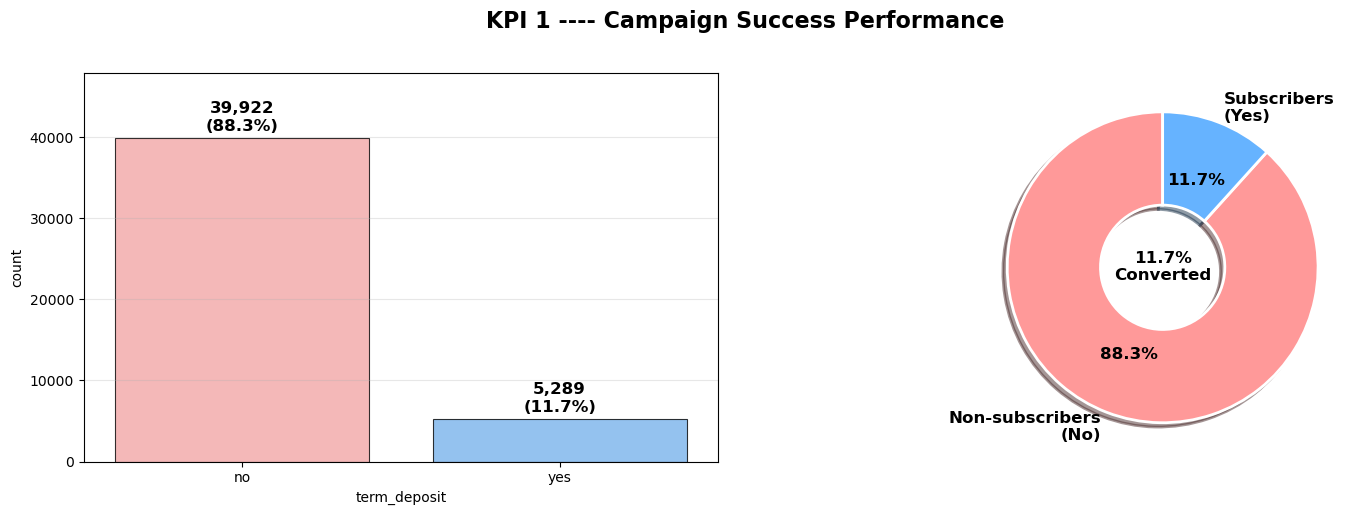


 INSIGHT : 11.7% of 45,211 contacts subscribed to term deposit.
  A total of 88.3% of campaign calls (39,922) failed to convert into subscriptions.
  Using these insights to target the right customers can increase campaign efficiency while reducing unnecessary outreach.


In [7]:
# _____Q1. Overall Campaign Success Rate_____________________________________________________________
fig, ax = plt.subplots(ncols = 2, figsize=(15, 5))

ax[0].grid(True, alpha=0.3)
sns.countplot(x=data['term_deposit'],palette=['#ff9999', '#66b3ff'],alpha=0.8, edgecolor='black', linewidth=0.8, ax=ax[0])

for i, v in enumerate(data['term_deposit'].value_counts()):
    ax[0].text(i, v+500, f'{v:,}\n({v/len(data)*100:.1f}%)',ha='center', va='bottom', fontsize=12,fontweight='bold' ,color='black')
ax[0].set_ylim(0, max(data['term_deposit'].value_counts())*1.2)


ax[1].pie(
    subscription_counts.values, labels=['Non-subscribers\n(No)', 'Subscribers\n(Yes)'], 
    autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'],  
    startangle=90, shadow=True,
    wedgeprops={'width': 0.6, 'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize':12, 'color':'k', 'weight':'bold'})
ax[1].text(0, 0, f"{subscription_percentages.get('yes', 0):.1f}%\nConverted", ha='center', va='center', fontsize=12, fontweight='bold')

fig.suptitle("KPI 1 ---- Campaign Success Performance", fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.2)
plt.show()

print(f"\n INSIGHT : {subscription_percentages.get('yes', 0):.1f}% of {len(data):,} contacts subscribed to term deposit.")
print(f"  A total of {subscription_percentages.get('no', 0):.1f}% of campaign calls ({subscription_counts["no"]:,}) failed to convert into subscriptions.")
print(f"  Using these insights to target the right customers can increase campaign efficiency while reducing unnecessary outreach.")



__Data is highly imbalanced, with a significant majority of customers not subscribing to the term deposit. This imbalance will need to be addressed in the modeling phase, possibly through techniques such as resampling or using algorithms that can handle class imbalance effectively.__

In [8]:
# Analyze class imbalance
yes_count = (data['term_deposit'] == 'yes').sum()
no_count = (data['term_deposit'] == 'no').sum()
imbalance_ratio = max(yes_count, no_count) / min(yes_count, no_count)

display_md("**CLASS IMBALANCE ANALYSIS**")
print("=" * 40)
print(f"Subscribed (yes): {yes_count:,} clients")
print(f"Not subscribed (no): {no_count:,} clients")
print(f"Imbalance ratio: {imbalance_ratio:.1f}:1")

if imbalance_ratio > 2:
    display_md("  **SIGNIFICANT CLASS IMBALANCE DETECTED !** ")
    print(" Consider using approachs like :")
    print(" - Stratified Sampling")
    print(" - SMOTE Oversampling Approach")
    print(" - Class Weights")
    print(" - Ensemble methods")
    print(" - Threshold Tuning")
    print(" - Cost-Sensitive Optimization")
else:
    print("Classes are relatively balanced")


**CLASS IMBALANCE ANALYSIS**

Subscribed (yes): 5,289 clients
Not subscribed (no): 39,922 clients
Imbalance ratio: 7.5:1


  **SIGNIFICANT CLASS IMBALANCE DETECTED !** 

 Consider using approachs like :
 - Stratified Sampling
 - SMOTE Oversampling Approach
 - Class Weights
 - Ensemble methods
 - Threshold Tuning
 - Cost-Sensitive Optimization


In [128]:
# Create a comprehensive statistical summary
display_md("**STATISTICAL SUMMARY**")
print("=" * 30)

# Confidence interval for subscription rate
from scipy import stats
subscription_rate = subscription_percentages.get('yes', 0)
n = len(data)
p = subscription_rate / 100
se = np.sqrt(p * (1 - p) / n)
ci_lower = (p - 1.96 * se) * 100
ci_upper = (p + 1.96 * se) * 100

print(f"Subscription rate: {subscription_rate:.2f}%")
print(f"95% Confidence Interval: [{ci_lower:.2f}%, {ci_upper:.2f}%]")
print(f"Standard Error: {se * 100:.3f}%")

# Sample size adequacy
print(f"\nSample size: {n:,}")
if n >= 1000:
    print("Large sample size - results are statistically robust")
elif n >= 100:
    print(" Moderate sample size - results are reasonably reliable")
else:
    print(" Small sample size - interpret results with caution")


**STATISTICAL SUMMARY**

Subscription rate: 11.70%
95% Confidence Interval: [11.40%, 11.99%]
Standard Error: 0.151%

Sample size: 45,211
Large sample size - results are statistically robust


##### __Q2. Age Group vs Conversion Rate__

In [9]:
# _____Q2. Age Group vs Conversion Rate__________________________________________________

# Analyze subscription rates across different demographic features
# will group age in different ways to accurately reflects customer behaviour
display_md("**SUBSCRIPTION RATES ACROSS DEMOGRAPHICS FEATURES**")
print("*"*60)

# By Age Groups
def categorize_age(age):
    if age < 30:
        return '18-30'
    elif age < 40:
        return '30-39'
    elif age < 50:
        return '40-49'
    elif age < 60:
        return '50-59'
    else:
        return '60+'

data['age_band'] = data['age'].apply(categorize_age)
age_bands = data.groupby('age_band')['term_deposit_numeric'].agg(['count', 'mean'])

display_md("**Across Age Band :**")
for age_band, success_rate in age_bands['mean'].items():
    count_age = (data['age_band'] == age_band).sum()
    print(f" {age_band} : {success_rate*100:.1f}% ({count_age:,} clients)")


**SUBSCRIPTION RATES ACROSS DEMOGRAPHICS FEATURES**

************************************************************


**Across Age Band :**

 18-30 : 17.6% (5,273 clients)
 30-39 : 10.6% (18,089 clients)
 40-49 : 9.1% (11,655 clients)
 50-59 : 9.3% (8,410 clients)
 60+ : 33.6% (1,784 clients)


In [10]:
# Age basket
bins = [18, 24, 34, 49, 66, 100]
labels = ['18-24', '25-34', '35-49', '50-66,', '67+']
data['age_basket'] = pd.cut(data['age'], bins=bins, labels=labels)

age_baskets = data.groupby('age_basket')['term_deposit_numeric'].agg(['count', 'mean'])

display_md("**by Age basket :**")
for age_basket, rate in age_baskets['mean'].items():
    age_count = (data['age_basket']==age_basket).sum()
    print(f"{age_basket} : {rate*100:.2f}% ({age_count:,} clients)")



**by Age basket :**

18-24 : 25.09% (797 clients)
25-34 : 12.48% (14,204 clients)
35-49 : 9.62% (20,004 clients)
50-66, : 11.46% (9,506 clients)
67+ : 43.02% (688 clients)


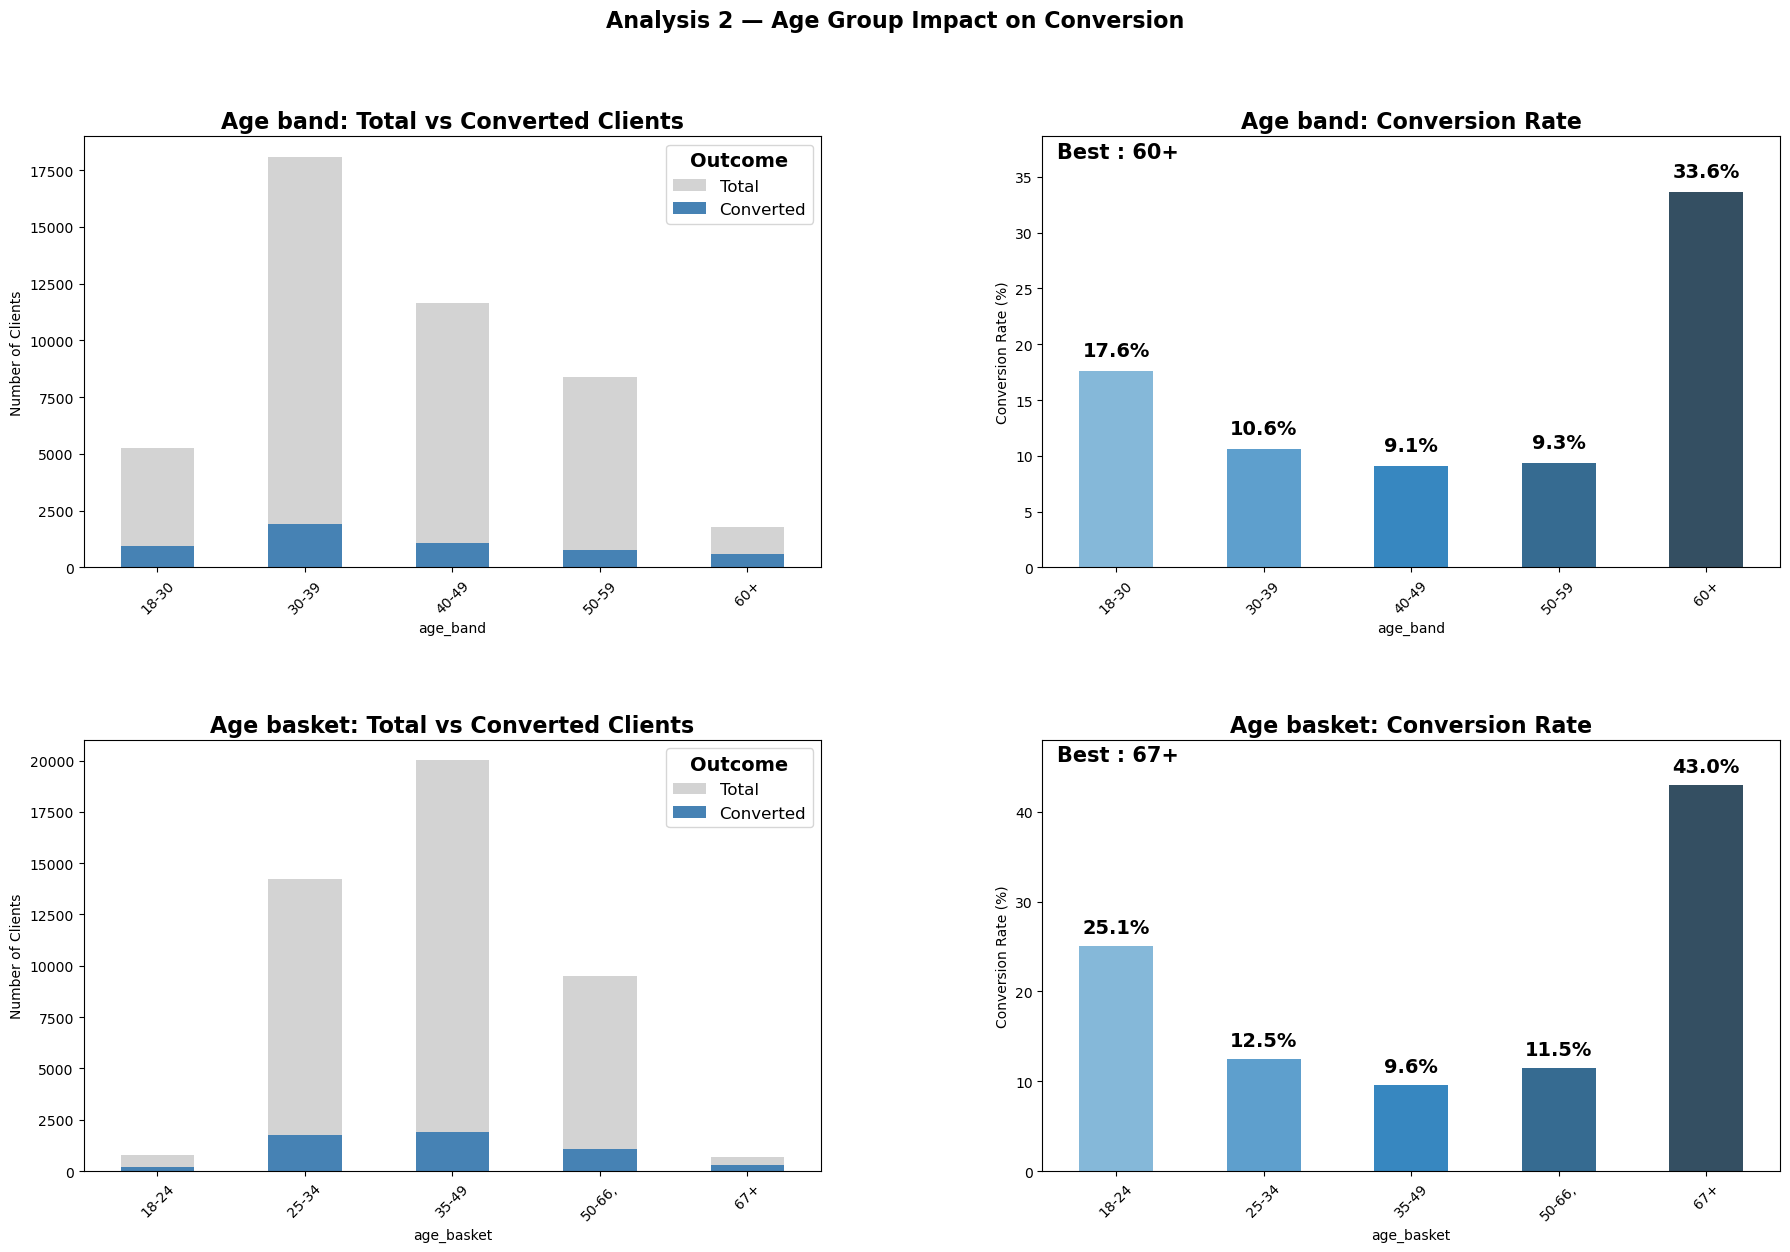

In [11]:
# Visualize both age_basket and age_band to determine which segmentation better captures customer behavior.

from matplotlib.font_manager import FontProperties

fig, ax = plt.subplots(2, 2, figsize=(18, 12))
ax = ax.flatten()

for i, col in enumerate(['age_band', 'age_basket']):

    summary = (data.groupby(col)['term_deposit']
                 .value_counts()
                 .unstack(fill_value=0))

    summary = summary.rename(columns={'yes':'Converted',
                                      'no':'Not Converted'})

    summary['Total'] = summary.sum(axis=1)
    summary['Conversion Rate'] = 100 * summary['Converted'] / summary['Total']

    # ---------------- Left: Stacked bar ----------------
    summary['Total'].plot(
        kind='bar',
        stacked=True,
        ax=ax[2*i],
        color='lightgray',
        label='Total'
    )
    summary['Converted'].plot(
        kind='bar',
        stacked=True,
        ax=ax[2*i],
        color='steelblue',
        label='Converted'
    )

    ax[2*i].set_title(f'{col.replace("_", " ").replace(".", " ").capitalize()}: Total vs Converted Clients', fontsize=16, fontweight='bold')
    ax[2*i].set_ylabel('Number of Clients')
    ax[2*i].tick_params(axis='x', rotation=45)
    ax[2*i].legend(title='Outcome', title_fontproperties=FontProperties(weight='bold', size=14), fontsize=12)

    # ---------------- Right: Conversion rate ----------------
    colors = sns.color_palette("Blues_d", len(summary))
    best_age = summary['Conversion Rate'].idxmax()

    summary['Conversion Rate'].plot(
        kind='bar',
        ax=ax[2*i+1],
        color=colors
    )
    # Annotate bars
    for j, (_, rates) in enumerate(summary['Conversion Rate'].items()):
        ax[2*i+1].text(j, rates+1, f"{rates:.1f}%", fontsize=14, fontweight='bold', ha='center', va='bottom')
    
    ax[2*i+1].text(0.02, 0.95, f"Best : {best_age}", transform=ax[2*i+1].transAxes, fontsize=15, fontweight='bold')
    
    ax[2*i+1].set_title(f'{col.replace("_", " ").replace(".", " ").capitalize()}: Conversion Rate', fontsize=16, fontweight='bold')
    ax[2*i+1].set_ylabel('Conversion Rate (%)')
    ax[2*i+1].set_ylim(0, summary['Conversion Rate'].max()+5)
    ax[2*i+1].tick_params(axis='x', rotation=45)

fig.suptitle('Analysis 2 — Age Group Impact on Conversion', fontsize=16, fontweight='bold', y=1.04)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()


In [12]:
# The `age_basket` feature reflects customer behavior and will therefore be included in further analysis.
age_baskets = data.groupby('age_basket')['term_deposit'].value_counts().unstack(fill_value=0)
age_baskets = age_baskets.assign(total_client=age_baskets.sum(axis=1))
age_baskets = age_baskets.assign(success_rate=(100 * age_baskets['yes']/age_baskets['total_client']))
display_md("**AGE GROUP CONVERSION DATA :**")
display(age_baskets) 
high = age_baskets['success_rate'].nlargest(2)
display_md(f"**INSIGHT : The highest conversion rate is observed in the {high.index[0]} age group ({high[0]:.1f}%), followed by the {high.index[1]} age group ({high[1]:.1f}%).**")
print("→ The bank should focus its marketing efforts on customers in these age baskets.")


**AGE GROUP CONVERSION DATA :**

term_deposit,no,yes,total_client,success_rate
age_basket,,,,
18-24,597,200,797,25.09
25-34,12431,1773,14204,12.48
35-49,18080,1924,20004,9.62
"50-66,",8417,1089,9506,11.46
67+,392,296,688,43.02


**INSIGHT : The highest conversion rate is observed in the 67+ age group (43.0%), followed by the 18-24 age group (25.1%).**

→ The bank should focus its marketing efforts on customers in these age baskets.


##### __Q3. Job Category vs Conversion Rate__

**Job Category Conversion Data :**

term_deposit     no   yes  total  success_rate
job                                           
student         669   269    938         28.68
retired        1748   516   2264         22.79
unemployed     1101   202   1303         15.50
management     8157  1301   9458         13.76
admin.         4540   631   5171         12.20
self-employed  1392   187   1579         11.84
unknown         254    34    288         11.81
technician     6757   840   7597         11.06
services       3785   369   4154          8.88
housemaid      1131   109   1240          8.79


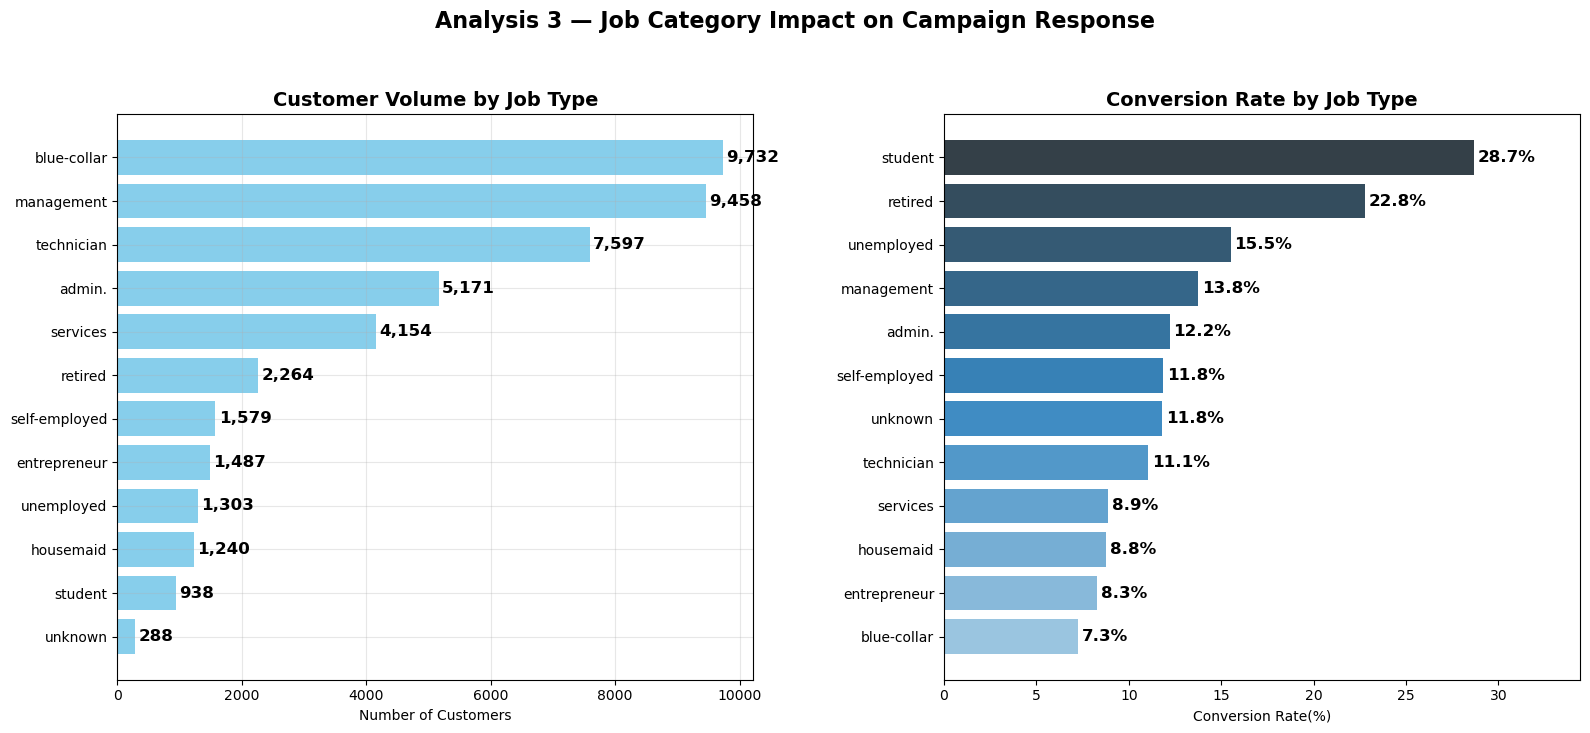

**TOP THREE CONVERTING JOB TYPES :**

term_deposit,success_rate,total
job,,
student,28.68,938
retired,22.79,2264
unemployed,15.50,1303


**BOTTOM THREE CONVERTING JO TYPES :**

term_deposit,success_rate,total
job,,
blue-collar,7.27,9732
entrepreneur,8.27,1487
housemaid,8.79,1240


**INSIGHT : Students and retired customers demonstrate relatively higher conversion rates than most other occupational groups.**

→ Despite representing a smaller proportion of the customer base, these segments should be prioritized in future marketing campaigns due to their higher conversion rates.


In [13]:
# ____Q3.Job Category vs Conversion Rate___________________________________________
job_category = data.groupby('job')['term_deposit'].value_counts().unstack(fill_value=0)
job_category = job_category.assign(total=job_category.sum(axis=1))
job_category = job_category.assign(success_rate=(100 * job_category['yes']/job_category['total']))
display_md("**Job Category Conversion Data :**")
print(job_category.sort_values(by='success_rate', ascending=False)[:10])

# visualization
fig, ax = plt.subplots(ncols=2, figsize=(16, 7))
# --------------------Left: customer volume per job----------------------
job_volume = job_category.sort_values(by='total', ascending=True)
colors = sns.color_palette("Blues_d", len(job_category))
ax[0].barh(job_volume.index, job_volume['total'], color='skyblue')

# Annotate bars
for i, (idx, count) in enumerate(job_volume['total'].items()):
    ax[0].text(count+50, i, f"{count:,}",va='center', fontsize=12, fontweight='bold')

ax[0].set_title('Customer Volume by Job Type',fontsize=14, fontweight='bold')
ax[0].set_xlabel("Number of Customers")
ax[0].grid(True, alpha=0.3)

# ------------------Right: converion rate per job-------------------------
job_success = job_category.sort_values(by='success_rate', ascending=True)
ax[1].barh(job_success.index, job_success['success_rate'],color=colors)

# Annotate bars
for j, (index, rates) in enumerate(job_success['success_rate'].items()):
    ax[1].text(rates+0.2, j, f"{rates:.1f}%", va='center', fontsize=12, fontweight='bold')

ax[1].set_title("Conversion Rate by Job Type", fontsize=14, fontweight='bold')
ax[1].set_xlabel("Conversion Rate(%)")
ax[1].set_xlim(0, (job_success['success_rate'].max() * 1.2))

fig.suptitle('Analysis 3 — Job Category Impact on Campaign Response', fontsize=16, fontweight='bold', y=1.04)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

top3 = job_category.nlargest(3, 'success_rate')[['success_rate', 'total']]
bottom3 = job_category.nsmallest(3, 'success_rate')[['success_rate', 'total']]
display_md("**TOP THREE CONVERTING JOB TYPES :**")
display(top3)
display_md("**BOTTOM THREE CONVERTING JO TYPES :**")
display(bottom3)
display_md("**INSIGHT : Students and retired customers demonstrate relatively higher conversion rates than most other occupational groups.**")
print("→ Despite representing a smaller proportion of the customer base, these segments should be prioritized in future marketing campaigns due to their higher conversion rates.")


##### __**Q4. Education Level vs Response**__

**Education Conversion TABLE :**

term_deposit     no   yes  total  success_rate
education                                     
tertiary      11305  1996  13301         15.01
unknown        1605   252   1857         13.57
secondary     20752  2450  23202         10.56
primary        6260   591   6851          8.63


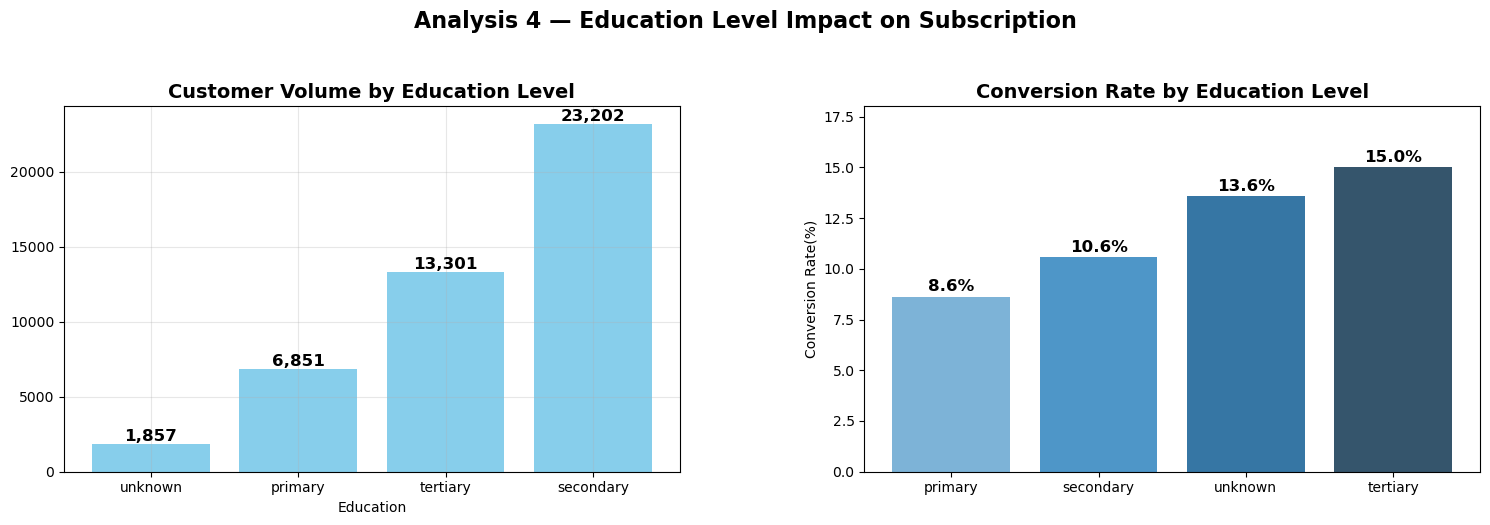

**INSIGHT : Customers with tertiary education generally exhibit the highest term deposit subscription rates, indicating that higher education is positively associated with campaign success.**

→ Prioritize customers with tertiary education, as they tend to have higher subscription rates and may offer a better return on marketing efforts.


In [ ]:
# _____Q4. Education Level vs Response__________________________________________
education_category = data.groupby('education')['term_deposit'].value_counts().unstack(fill_value=0)
education_category = education_category.assign(total=education_category.sum(axis=1))
education_category = education_category.assign(success_rate=(100 * education_category['yes']/education_category['total']))
display_md("**Education Conversion TABLE :**")
print(education_category.sort_values(by='success_rate', ascending=False))

# visualization
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))
# --------------------Left: customer volume per education----------------------
education_volume = education_category.sort_values(by='total', ascending=True)
colors = sns.color_palette("Blues_d", len(education_category.index))
ax[0].bar(education_volume.index, education_volume['total'], color='skyblue')

# Annotate bars
for i, (idx, count) in enumerate(education_volume['total'].items()):
    ax[0].text(i, count+500, f"{count:,}", ha='center',va='center', fontsize=12, fontweight='bold')

ax[0].set_title('Customer Volume by Education Level',fontsize=14, fontweight='bold')
ax[0].set_xlabel("Education")
ax[0].grid(True, alpha=0.3)

# ------------------Right: converion rate per education-------------------------
education_success = education_category.sort_values(by='success_rate', ascending=True)
ax[1].bar(education_success.index, education_success['success_rate'],color=sns.color_palette("Blues_d", len(education_success.index)))

# Annotate bars
for j, (index, rates) in enumerate(education_success['success_rate'].items()):
    ax[1].text(j, rates+0.5, f"{rates:.1f}%", ha='center', va='center', fontsize=12, fontweight='bold')

ax[1].set_title("Conversion Rate by Education Level", fontsize=14, fontweight='bold')
ax[1].set_ylabel("Conversion Rate(%)")
ax[1].set_ylim(0, (education_success['success_rate'].max() * 1.2))

fig.suptitle('Analysis 4 — Education Level Impact on Subscription', fontsize=16, fontweight='bold', y=1.04)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

display_md("**INSIGHT : Customers with tertiary education generally exhibit the highest term deposit subscription rates, indicating that higher education is positively associated with campaign success.**")
print("→ Prioritize customers with tertiary education, as they tend to have higher subscription rates and may offer a better return on marketing efforts.")


##### __Q5. Housing & Personal Loan vs Response__

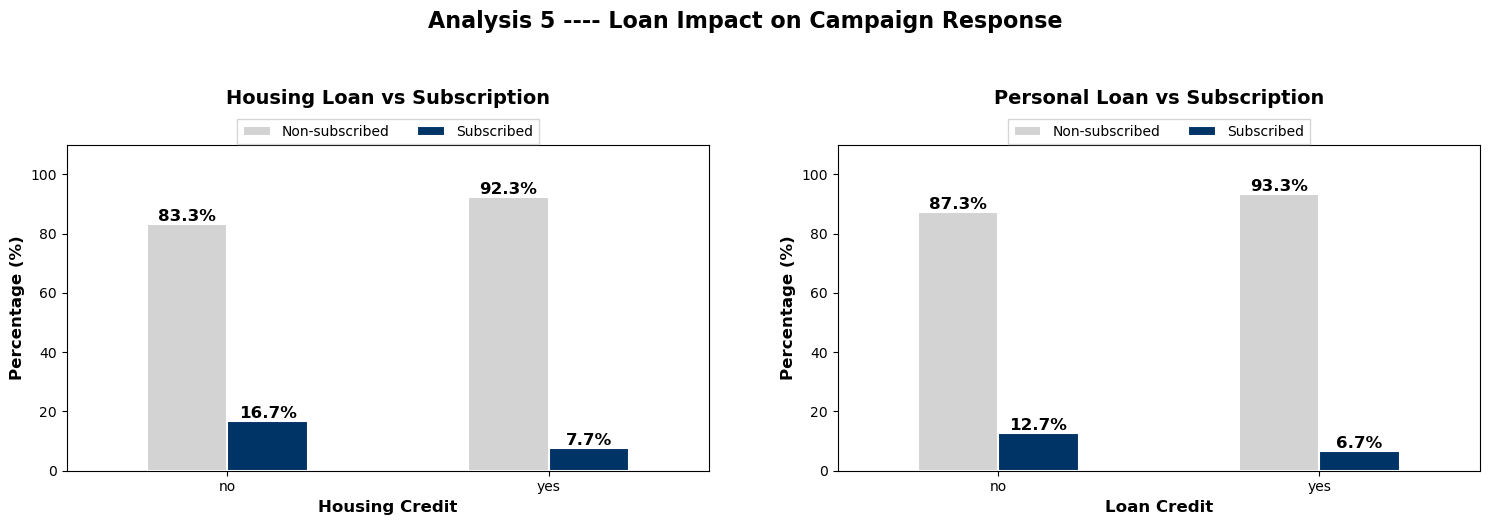

**INSIGHT : Customers WITHOUT a housing loan convert at 16.7% vs 7.7% for those WITH one.**

→ Customers with housing loans are less likely to subscribe due to existing debt commitments.
→ Customers without existing loans are more likely to subscribe to term deposits, suggesting that greater financial flexibility may increase the likelihood of investment.


In [ ]:
# ____Q5. Housing & Personal Loan vs Response____________________________________________
from matplotlib.font_manager import FontProperties
fig, axes = plt.subplots(ncols=2, figsize=(15, 5))

for ax, col, title in zip(axes, 
                          ['housing', 'loan'],
                          ('Housing Loan vs Subscription', 'Personal Loan vs Subscription')):
    cross_tab = pd.crosstab(data[col], data['term_deposit'], normalize='index')*100
    cross_tab.plot(kind='bar', ax=ax, color=['lightgrey', '#003366'],
                   edgecolor='white', lw=1.5, rot=0)
    # Annotate the bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', y=1.10)
    ax.set_xlabel(col.capitalize() + ' Credit', fontsize=12, fontweight='bold')
    ax.set_ylabel("Percentage (%)", fontsize=12, fontweight='bold')
    ax.set_ylim(0, 110)
    ax.legend(labels=['Non-subscribed', 'Subscribed'], 
              title_fontproperties = FontProperties(weight='bold',size=14), 
              fontsize=10, ncol=3, loc='upper center', bbox_to_anchor= (0.5, 1.10), fancybox=False)
    
fig.suptitle("Analysis 5 ---- Loan Impact on Campaign Response", fontsize=16, fontweight='bold', y=1.04)
plt.tight_layout()
plt.subplots_adjust(wspace=0.2)
plt.show()

no_housing_success = data[data['housing']=='no']['term_deposit_numeric'].mean()*100
yes_housing_success= data[data['housing']=='yes']['term_deposit_numeric'].mean()*100
display_md(f'**INSIGHT : Customers WITHOUT a housing loan convert at {no_housing_success:.1f}%'
      f' vs {yes_housing_success:.1f}% for those WITH one.**')
print('→ Customers with housing loans are less likely to subscribe due to prior debt commitments.')
print('→ Customers without existing loans are more likely to subscribe to term deposits, suggesting that greater financial flexibility may increase the likelihood of investment.')



##### __Q6. Account balance vs Subscription__

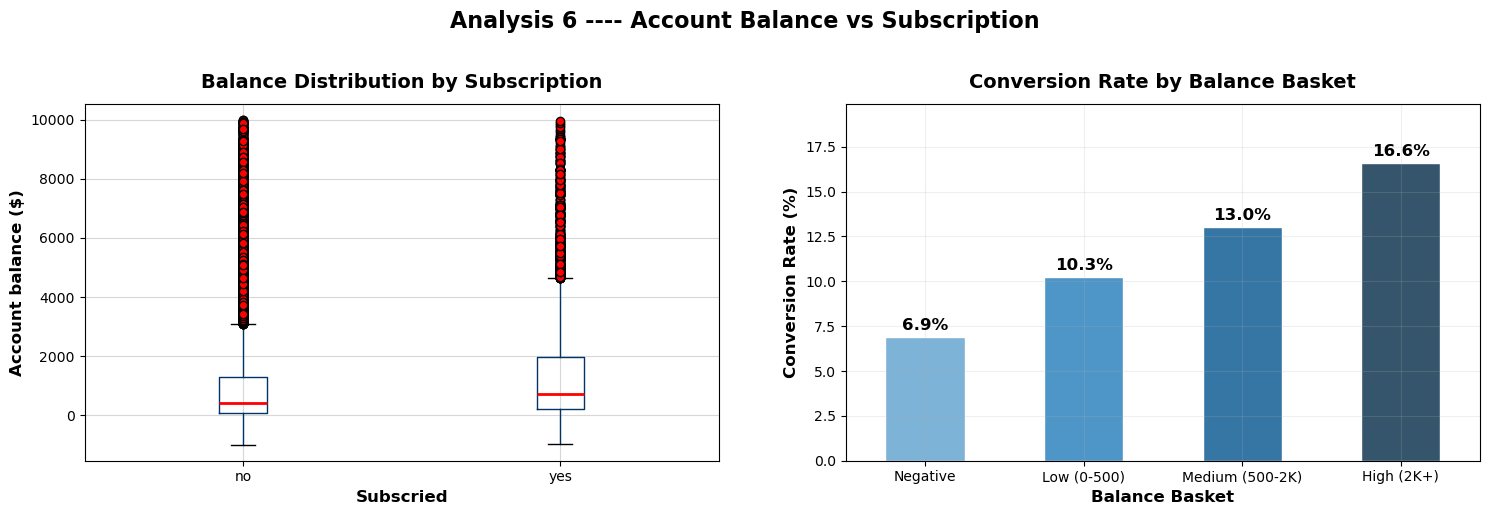

**Balance Basket Conversion Rate :**

balance_basket
Negative           6.90
Low (0-500)       10.25
Medium (500-2K)   13.02
High (2K+)        16.57
Name: success_rate, dtype: float64

**INSIGHT : Customers with higher account balances are more likely to subscribe to term deposits.**

→ Wealthy customers are more likely to view term deposits as a secure savings option.
→ Focus marketing efforts on high-balance customers to maximize campaign returns (ROI).


In [ ]:
# _____Q6. Account balance vs Subscription____________________________________________________

# balance basket
bin = [-999999, 0, 500, 2000, 999999]
label = ['Negative', 'Low (0-500)', 'Medium (500-2K)', 'High (2K+)']

data['balance_basket'] = pd.cut(data['balance'], bins=bin, labels=label)

# Visualization
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))
#---------------Left: boxplot for distribution------------------------------------------------------------------
data_box = data[data['balance'].between(-1000, 10000)].copy()       # Remove extreme outliers for visibility
data_box.boxplot(column='balance', by='term_deposit', ax=ax[0],
                #fill=False, color='k',
                boxprops={'color':'#003366'}, 
                whiskerprops={'color':'#003366'},
                medianprops={'color':'r', 'lw':2},
                flierprops={'marker':'o', 'markerfacecolor':'r'}
)
ax[0].set_title('Balance Distribution by Term Deposit', fontsize=14, fontweight='bold', y=1.02)
ax[0].set_xlabel("Subscried", fontsize=12, fontweight='bold')
ax[0].set_ylabel('Account balance ($)', fontsize=12, fontweight='bold')
ax[0].grid(True, alpha=0.5)

#-----------------Right: Conversion Rate--------------------------------------------------------------------------
balance_success = data.groupby('balance_basket', observed=True)['term_deposit'].value_counts().unstack(fill_value=0)
balance_success = balance_success.assign(total=balance_success.sum(axis=1))
balance_success = balance_success.assign(success_rate=(100 * balance_success['yes'] / balance_success['total']))

balance_success['success_rate'].plot(
    kind='bar', ax=ax[1],
    color=sns.color_palette(palette='Blues_d', n_colors = balance_success.index.nunique()),
    edgecolor='white', rot=0
)
# Annotate the bar
for i, val in enumerate(balance_success['success_rate']):
    ax[1].text(i, val+0.4, f"{val:.1f}%", ha='center', fontsize=12, fontweight='bold')

ax[1].set_title("Conversion Rate by Balance Basket", fontsize=14, fontweight='bold', y=1.02)
ax[1].set_xlabel("Balance Basket", fontsize=12, fontweight='bold')
ax[1].set_ylabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
ax[1].set_ylim(0, balance_success['success_rate'].max() * 1.2)
ax[1].grid(True, alpha=0.2)

fig.suptitle("Analysis 6 ---- Account Balance vs Subscription", fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2)
plt.show()

display_md("**Balance Basket Conversion Rate :**")
display(balance_success['success_rate'])
display_md("**INSIGHT : Customers with higher account balances are more likely to subscribe to term deposits.**")
print("→ Wealthy customers are more likely to view term deposits as a secure savings option.")
print("→ Focus marketing efforts on high-balance customers to maximize campaign returns (ROI).")



##### __Q7. Month-wise Campaign Response__

In [17]:
# ______Q7. Month-wsie Campaign Response__________________________________________________________
# Subscription rates by month and day of week
display_md("**SEASONAL ANALYSIS**")
print("=" * 30)

# By month
month_subscription = data.groupby('month')['term_deposit'].apply(lambda x: (x == 'yes').mean() * 100)
print("Subscription Rate by Month:")
for month, rate in month_subscription.items():
    count = (data['month'] == month).sum()
    print(f"  {month}: {rate:.1f}% ({count:,} clients)")

# By day of week
day_subscription = data.groupby('day')['term_deposit'].apply(lambda x: (x == 'yes').mean() * 100)
print(f"\nSubscription Rate by Day of Week:")
for day, rate in day_subscription.items():
    count = (data['day'] == day).sum()
    print(f"  {day}: {rate:.1f}% ({count:,} clients)")

**SEASONAL ANALYSIS**

Subscription Rate by Month:
  apr: 19.7% (2,932 clients)
  aug: 11.0% (6,247 clients)
  dec: 46.7% (214 clients)
  feb: 16.6% (2,649 clients)
  jan: 10.1% (1,403 clients)
  jul: 9.1% (6,895 clients)
  jun: 10.2% (5,341 clients)
  mar: 52.0% (477 clients)
  may: 6.7% (13,766 clients)
  nov: 10.2% (3,970 clients)
  oct: 43.8% (738 clients)
  sep: 46.5% (579 clients)

Subscription Rate by Day of Week:
  1: 28.0% (322 clients)
  2: 14.1% (1,293 clients)
  3: 16.5% (1,079 clients)
  4: 15.9% (1,445 clients)
  5: 11.3% (1,910 clients)
  6: 9.4% (1,932 clients)
  7: 8.6% (1,817 clients)
  8: 10.9% (1,842 clients)
  9: 11.5% (1,561 clients)
  10: 23.1% (524 clients)
  11: 12.2% (1,479 clients)
  12: 15.2% (1,603 clients)
  13: 15.2% (1,585 clients)
  14: 11.4% (1,848 clients)
  15: 14.0% (1,703 clients)
  16: 13.6% (1,415 clients)
  17: 9.1% (1,939 clients)
  18: 9.9% (2,308 clients)
  19: 6.9% (1,757 clients)
  20: 7.0% (2,752 clients)
  21: 9.9% (2,026 clients)
  22: 17.0% (905 clients)
  23

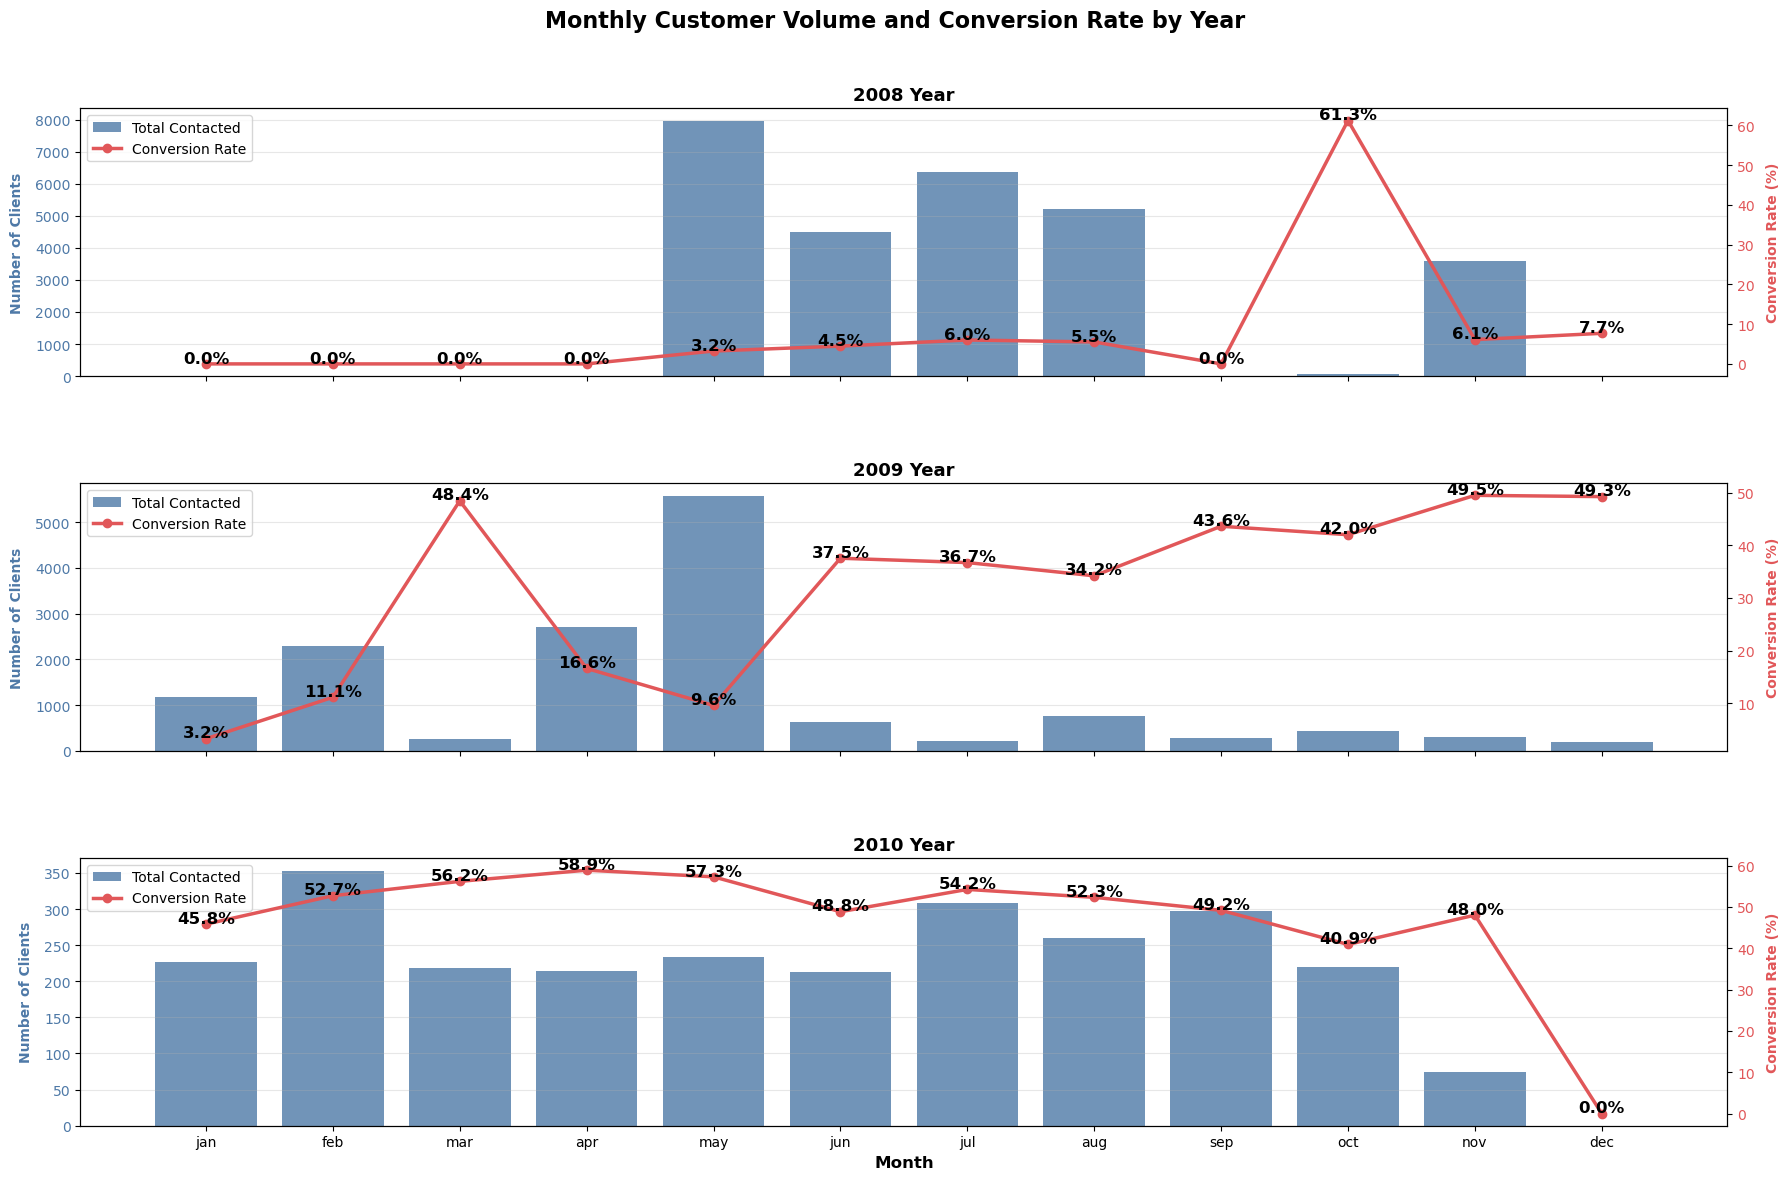

In [131]:
# Visualize monthly and yearly trends in customer volume and conversion rates.

fig, axes = plt.subplots(nrows=3, figsize=(18, 12), sharex=True)

month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']

for i, year_category in enumerate(sorted(data['year'].unique())):

    # Monthly statistics
    monthly = (
        data[data['year'] == year_category]
        .groupby('month')['term_deposit']
        .value_counts()
        .unstack(fill_value=0)
        .reindex(month_order)
        .fillna(0)
    )

    monthly['total'] = monthly.sum(axis=1)
    monthly['success_rate'] = (
        monthly['yes']
        .div(monthly['total'])
        .fillna(0)
        .mul(100)
    )

    ax1 = axes[i]

    # Bar chart
    ax1.bar(
        monthly.index,
        monthly['total'],
        color='#4E79A7',
        alpha=0.8,
        label='Total Contacted'
    )

    ax1.set_ylabel('Number of Clients', color='#4E79A7', fontweight='bold', labelpad=8)
    ax1.tick_params(axis='y', labelcolor='#4E79A7')

    # Second axis
    ax2 = ax1.twinx()

    ax2.plot(
        monthly.index,
        monthly['success_rate'],
        color='#E15759',
        marker='o',
        linewidth=2.5,
        label='Conversion Rate'
    )

    ax2.set_ylabel('Conversion Rate (%)',
                   color='#E15759',
                   fontweight='bold',
                   labelpad=8)
    ax2.tick_params(axis='y', labelcolor='#E15759')

    # Labels
    for j, rate in enumerate(monthly['success_rate']):
        ax2.text(j, rate + 0.3,
                 f'{rate:.1f}%',
                 ha='center',
                 fontsize=12,
                 color='k',
                 fontweight='bold')

    ax1.set_title(f'{year_category} Year', fontsize=13, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)

    # Combined legend
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc='upper left')

# X-axis label only on bottom subplot
axes[-1].set_xlabel('Month', fontsize=12, fontweight='bold')

fig.suptitle(
    'Monthly Customer Volume and Conversion Rate by Year',
    fontsize=16,
    fontweight='bold',
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.subplots_adjust(hspace=0.4)
plt.show()

##### **Q8. Call Duration vs Conversion**

In [20]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'term_deposit', 'term_deposit_numeric',
       'age_group', 'balance_category', 'duration_category',
       'contact_frequency_category', 'pdays_category', 'previous_category',
       'year', 'month_numeric', 'year_month', 'age_band', 'age_basket',
       'balance_basket', 'month_order'],
      dtype='object')

In [21]:
# ____Q8. Call Duration vs Conversion_______________________________________________________________________

# Analyze subscription success by campaign characteristics
display_md("**SUBSCRIPTION RATES BY CAMPAIGN CHARACTERISTICS**")
print("=" * 55)

# Analysis by call duration categories
def categorize_duration(duration):
    if duration == 0:
        return 'No Contact'
    elif duration <= 120:
        return 'Short (≤2 min)'
    elif duration <= 300:
        return 'Medium (2-5 min)'
    elif duration <= 600:
        return 'Long (5-10 min)'
    else:
        return 'Very Long (>10 min)'

data['duration_band'] = data['duration'].apply(categorize_duration)
duration_subscription = data.groupby('duration_band')['term_deposit'].apply(lambda x: (x == 'yes').mean() * 100)

print()
display_md(f"**By Call Duration :**")
for duration_cat, rate in duration_subscription.items():
    count = (data['duration_band'] == duration_cat).sum()
    print(f"  {duration_cat}: {rate:.1f}% ({count:,} clients)")


**SUBSCRIPTION RATES BY CAMPAIGN CHARACTERISTICS**

**By Call Duration :**

  Long (5-10 min): 19.2% (8,484 clients)
  Medium (2-5 min): 8.6% (18,893 clients)
  No Contact: 0.0% (3 clients)
  Short (≤2 min): 1.5% (14,041 clients)
  Very Long (>10 min): 48.4% (3,790 clients)


In [22]:
# Call Duration in Minutes
data['duration_mins'] = (data['duration'] / 60).round(2)

# Duration Buckets
data['duration_bucket'] = pd.cut(
    data['duration'],
    bins=[0, 60, 180, 300, 600, 99999],
    labels=['<1 min', '1-3 mins', '3-5 mins', '5-10 mins', '10+ mins']
)
duration_conversion = data.groupby('duration_bucket', observed=True)['term_deposit'].apply(lambda x: (x=='yes').mean()*100)

display_md(f"**By Call Duration Buckets:**")
for duration_call, rates in duration_conversion.items():
    count = (data['duration_bucket'] == duration_call).sum()
    print(f"  {duration_call}: {rates:.1f}% ({count:,} clients)")



**By Call Duration Buckets:**

  <1 min: 0.2% (4,763 clients)
  1-3 mins: 3.9% (17,894 clients)
  3-5 mins: 10.9% (10,277 clients)
  5-10 mins: 19.2% (8,484 clients)
  10+ mins: 48.4% (3,790 clients)


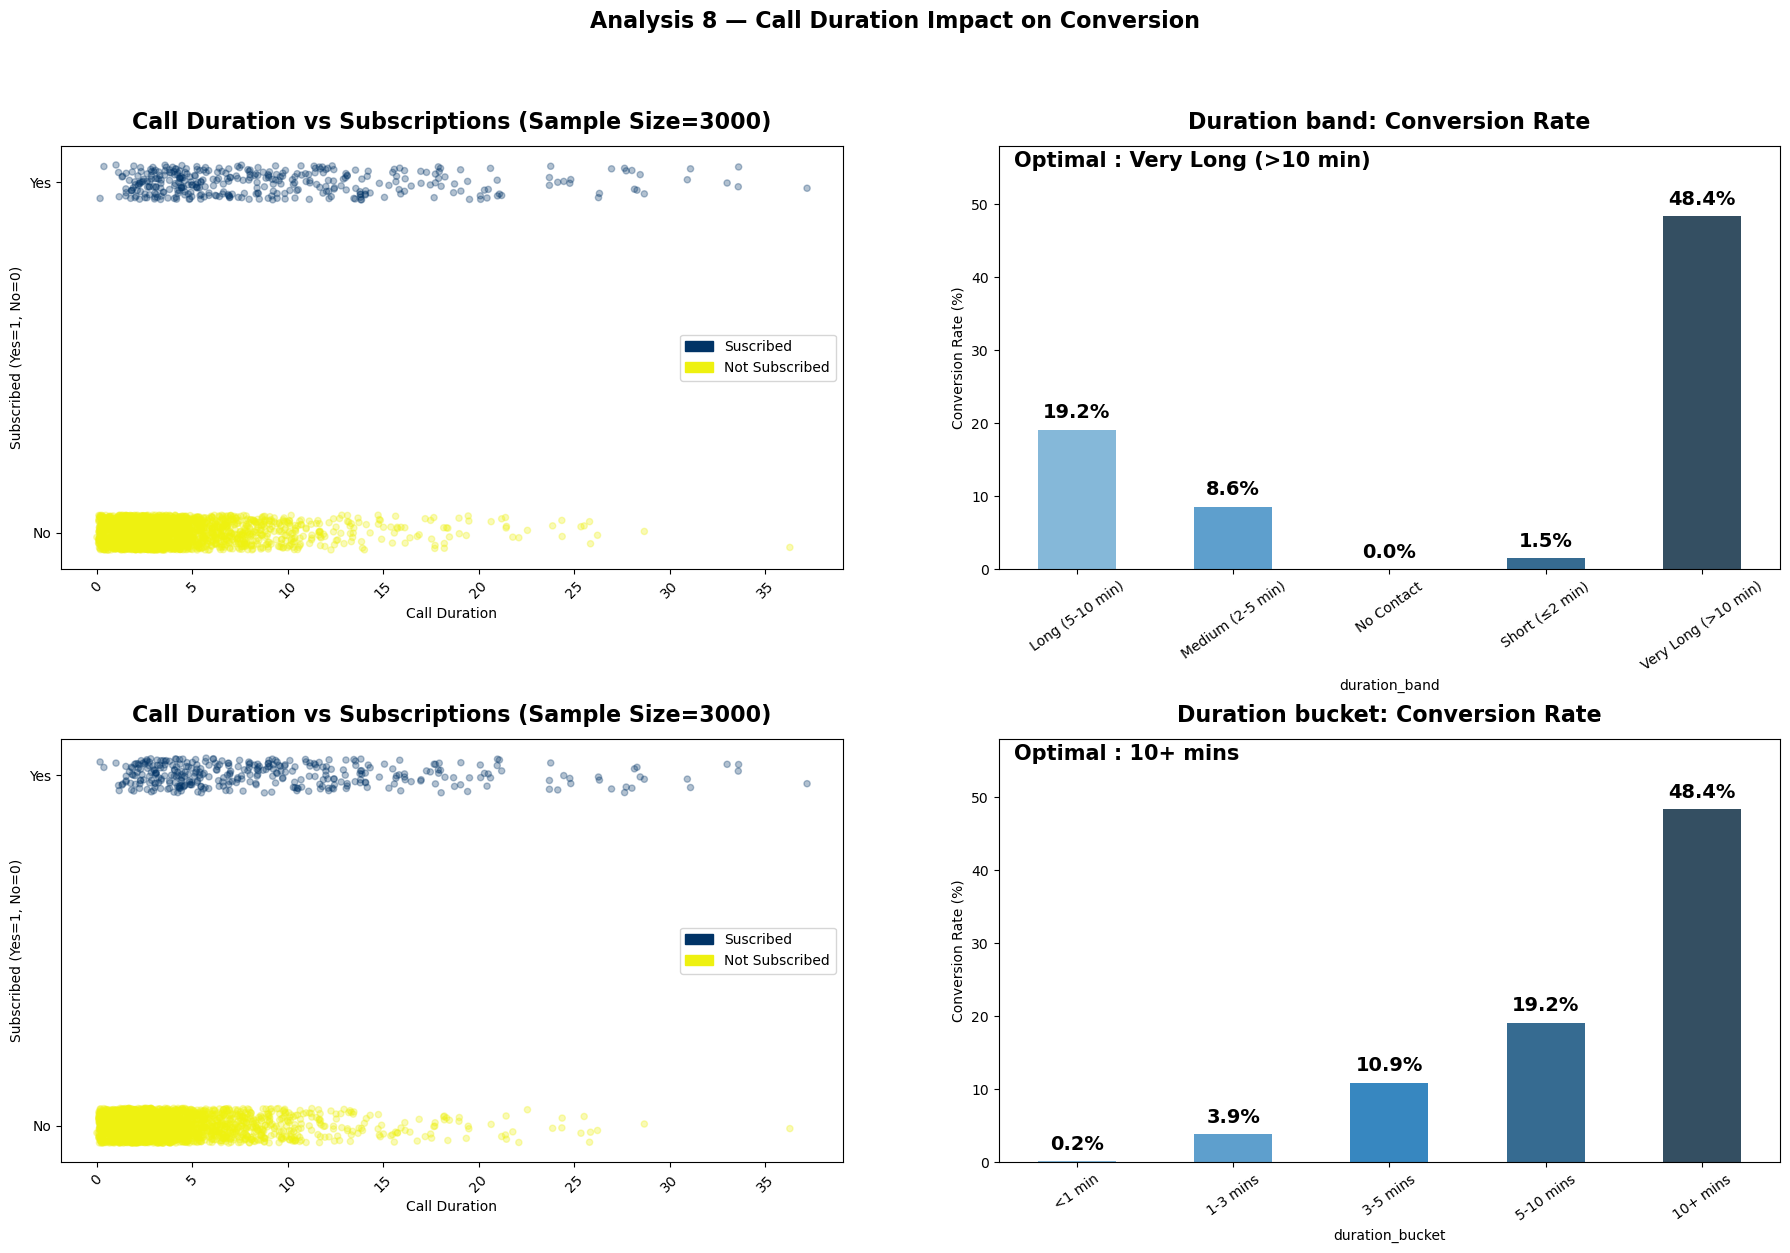

In [23]:
# Visualize both duration_band and duration_bucket to determine which segmentation better captures customer behavior.

from matplotlib.font_manager import FontProperties
from matplotlib.patches import Patch
fig, ax = plt.subplots(2, 2, figsize=(18, 12))
ax = ax.flatten()

for i, col in enumerate(['duration_band', 'duration_bucket']):

    summary = (data.groupby(col)['term_deposit']
                 .value_counts()
                 .unstack(fill_value=0))

    summary = summary.rename(columns={'yes':'converted',
                                      'no':'not_converted'})

    summary['total'] = summary.sum(axis=1)
    summary['conversion_rate'] = 100 * summary['converted'] / summary['total']

    # ---------------- Left: Scatter Plot ----------------------------------------
    sample_df = data.sample(n=3000, random_state=42)    # Sample for readability
    ax[2*i].scatter(sample_df['duration']/60, sample_df['term_deposit_numeric']+np.random.uniform(-0.05, 0.05, len(sample_df)), 
                  c=['#003366' if y==1 else "#eef110" for y in sample_df['term_deposit_numeric']],
                  alpha=0.3, s=20)
    

    ax[2*i].set_title('Call Duration vs Subscriptions (Sample Size=3000)', fontsize=16, fontweight='bold', y=1.02)
    ax[2*i].set_ylabel('Subscribed (Yes=1, No=0)')
    ax[2*i].set_xlabel("Call Duration")
    ax[2*i].tick_params(axis='x', rotation=45)
    ax[2*i].set_yticks([0, 1])
    ax[2*i].set_yticklabels(['No', 'Yes'])
    legend_elements = [
        Patch(color='#003366', label='Suscribed'),
        Patch(color='#eef110', label='Not Subscribed')
    ] 
    ax[2*i].legend(handles=legend_elements)

    #ax[2*i].legend(title='Outcome', title_fontproperties=FontProperties(weight='bold', size=14), fontsize=12)

    # ---------------- Right: Conversion rate ----------------
    colors = sns.color_palette("Blues_d", len(summary))
    optimal_duration = summary['conversion_rate'].idxmax()

    summary['conversion_rate'].plot(
        kind='bar',
        ax=ax[2*i+1],
        color=colors
    )
    # Annotate bars
    for j, (_, rates) in enumerate(summary['conversion_rate'].items()):
        ax[2*i+1].text(j, rates+1, f"{rates:.1f}%", fontsize=14, fontweight='bold', ha='center', va='bottom')
    
    ax[2*i+1].text(0.02, 0.95, f"Optimal : {optimal_duration}", transform=ax[2*i+1].transAxes, fontsize=15, fontweight='bold')
    
    ax[2*i+1].set_title(f'{col.replace("_", " ").replace(".", " ").capitalize()}: Conversion Rate', fontsize=16, fontweight='bold', y=1.02)
    ax[2*i+1].set_ylabel('Conversion Rate (%)')
    ax[2*i+1].set_ylim(0, summary['conversion_rate'].max() * 1.2)
    ax[2*i+1].tick_params(axis='x', rotation=35)

fig.suptitle('Analysis 8 — Call Duration Impact on Conversion', fontsize=16, fontweight='bold', y=1.04)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.4)
plt.show()


In [24]:
# The `duration_bucket` feature reflects customer behavior and will therefore be included in further analysis.
avg_yes = data.query("term_deposit=='yes'")['duration'].mean()/60
avg_no = data.query("term_deposit=='no'")['duration'].mean()/60

print(f"\nAverage Call Duration – Subscribed : {avg_yes:.1f} minutes | Not Subscribed : {avg_no:.1f} minutes")
print(f"Subscribed customers talks {avg_yes/avg_no:.1f}x longer on average.")

display_md(f"**INSIGHT: Longer call durations are associated with higher conversion rates.**")
print("Calls > 5 minutes achieve the highest conversion rates.")
print("→ Encourage call agents to have longer conversations and address customer concerns rather than cutting calls short.")



Average Call Duration – Subscribed : 9.0 minutes | Not Subscribed : 3.7 minutes
Subscribed customers talks 2.4x longer on average.


**INSIGHT: Longer call durations are associated with higher conversion rates.**

Calls > 5 minutes achieve the highest conversion rates.
→ Encourage call agents to have longer conversations and address customer concerns rather than cutting calls short.


---
## **5. Campaign Performance Analysis**

This phase shifts the focus from **who responds** to **how the marketing campaign was conducted**.

**Key questions:**

* Does contacting a customer multiple times improve or reduce the likelihood of subscription?
* Does the outcome of a previous campaign influence current campaign success?
* Which contact method (cellular or telephone) is more effective?


##### __Q9. Campaign Contact Frequency vs Conversion Rate__


By Number of Contacts in Current Campaign:
  1 contact(s): 14.6% (17,544 clients)
  2 contact(s): 11.2% (12,505 clients)
  3 contact(s): 11.2% (5,521 clients)
  4 contact(s): 9.0% (3,522 clients)
  5 contact(s): 7.9% (1,764 clients)
  6 contact(s): 7.1% (1,291 clients)
  7 contact(s): 6.4% (735 clients)
  8 contact(s): 5.9% (540 clients)
  9 contact(s): 6.4% (327 clients)
  10 contact(s): 5.3% (266 clients)


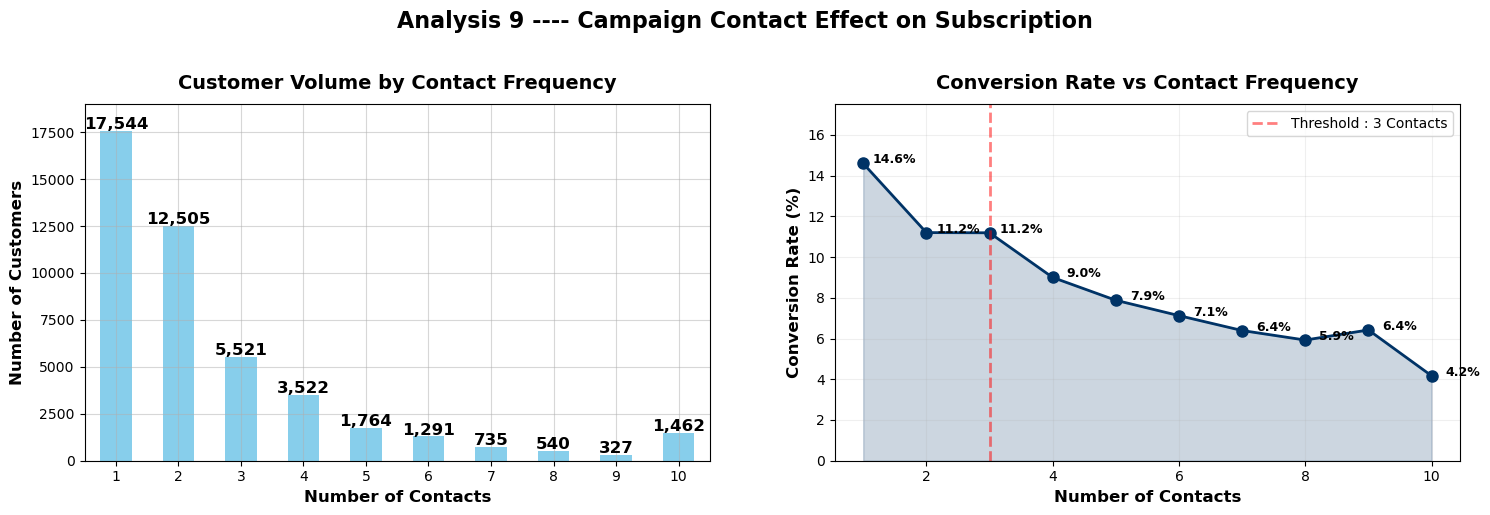

**Contact Frequency Conversion Rate :**

Conversion Rate after 1 Contact : 14.6%
Conversion Rate after 3 Contact : 11.2%


**INSIGHT : Conversion rates decrease consistently after three customer contacts.**

→ Most successful conversions occur within the first three customer contacts.
→ Keep customer contact attempts within three to optimize costs and prevent over-contacting.


In [86]:
# ___Q9. Campaign Contact Frequency vs Conversion Rate___________________________________________________________________________
# number of contacts
campaign_subscription = data.groupby('campaign')['term_deposit'].apply(lambda x: (x == 'yes').mean() * 100)
print("\nBy Number of Contacts in Current Campaign:")
for contacts, rate in campaign_subscription[:10].items():
    count = (data['campaign'] == contacts).sum()
    print(f"  {contacts} contact(s): {rate:.1f}% ({count:,} clients)")

# Cap at 10+ to avoid noise from outliers
data['campaign_capped'] = data['campaign'].clip(upper=10)
campaign_success = data.groupby('campaign_capped')['term_deposit'].value_counts().unstack(fill_value=0)
campaign_success = campaign_success.assign(total=campaign_success.sum(axis=1))
campaign_success = campaign_success.assign(success_rate = (100 * campaign_success['yes']/campaign_success['total']))

# Visualization
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))
#---------------Left: customer volume per contact count------------------------------------------------------------------
campaign_success['total'].plot(kind='bar', ax=ax[0], color='skyblue', rot=0)
ax[0].set_ylim(0, 19000)

# Annotate bars
for i, count in enumerate(campaign_success['total']):
    ax[0].text(i, count+100, f"{count:,}", ha='center', fontsize=12, fontweight='bold')

ax[0].set_title('Customer Volume by Contact Frequency', fontsize=14, fontweight='bold', y=1.02)
ax[0].set_xlabel("Number of Contacts", fontsize=12, fontweight='bold')
ax[0].set_ylabel('Number of Customers', fontsize=12, fontweight='bold')
ax[0].grid(True, alpha=0.5)

#-----------------Right: Conversion Rate--------------------------------------------------------------------------

# campaign_success['success_rate'].plot(
#     kind='bar', ax=ax[1],
#     color=sns.color_palette(palette='Blues_d', n_colors = balance_success.index.nunique()),
#     edgecolor='white', rot=0
# )
ax[1].plot(campaign_success.index, campaign_success['success_rate'],
           marker='o', markersize=8, lw=2, color='#003366')
ax[1].fill_between(campaign_success.index, campaign_success['success_rate'],
                   alpha=0.2, color='#003366')
# Annotate the bar
for i, val in enumerate(campaign_success['success_rate']):
    ax[1].text(i+1.5, val, f"{val:.1f}%", ha='center', fontsize=9, fontweight='bold')
# vertical line at x=3
ax[1].axvline(x=3, ls='--', lw=2, color='r', label='Threshold : 3 Contacts', alpha=0.5)

ax[1].legend()
ax[1].set_title("Conversion Rate vs Contact Frequency", fontsize=14, fontweight='bold', y=1.02)
ax[1].set_xlabel("Number of Contacts", fontsize=12, fontweight='bold')
ax[1].set_ylabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
ax[1].set_ylim(0, campaign_success['success_rate'].max() * 1.2)
ax[1].grid(True, alpha=0.2)

fig.suptitle("Analysis 9 ---- Campaign Contact Effect on Subscription", fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2)
plt.show()

contact_1 = campaign_success['success_rate'].idxmax()
contact_1_rate = campaign_success['success_rate'].max()
contact_3_rate = campaign_success[campaign_success.index==3]['success_rate'].values[0]
display_md("**Contact Frequency Conversion Rate :**")
print(f"Conversion Rate after {contact_1} Contact : {contact_1_rate:.1f}%")
print(f"Conversion Rate after 3 Contact : {contact_3_rate:.1f}%")
display_md("**INSIGHT : Conversion rates decrease consistently after three customer contacts.**")
print("→ Most successful conversions occur within the first three customer contacts.")
print("→ Keep customer contact attempts within three to optimize costs and prevent over-contacting.")


##### __Q10. Previous Campaign Outcome vs Current Response__

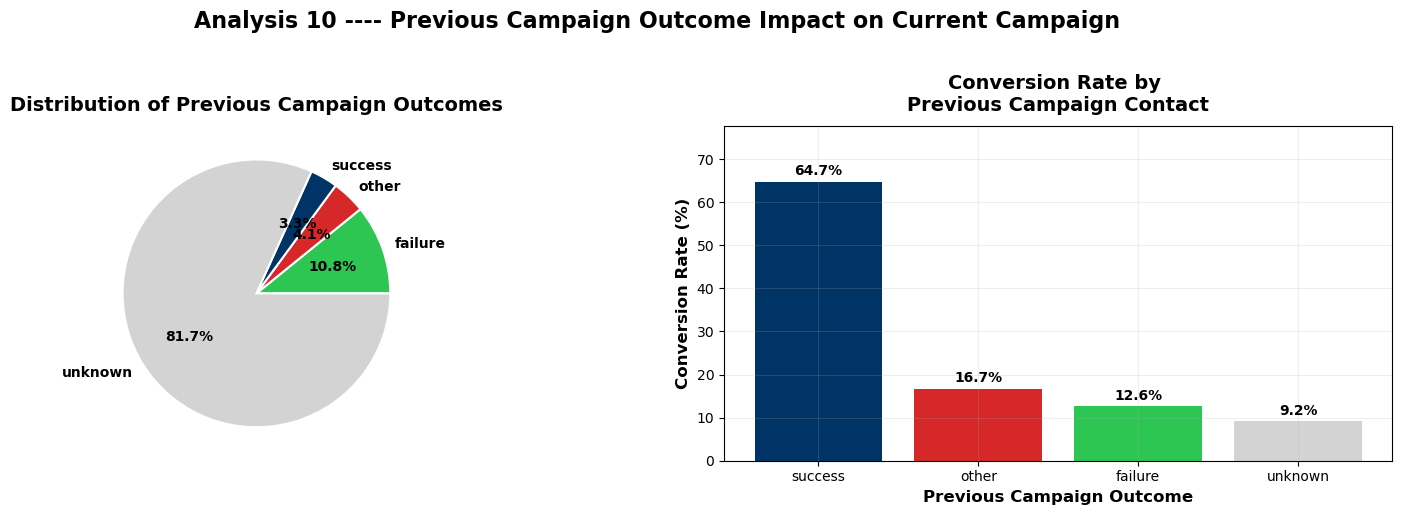

**Poutcome Distribution :**

Maximum contact during current campaign : unknown (36,959) with (9.2% conversion rate)
Highest Conversion Rate Outcome : success (64.7%)
→ 7.1x higher conversion from previously successful customers!


**INSIGHT : A successful previous campaign is the most influential factor in predicting current conversion.**

→ Prioritize customers who responded positively in previous campaigns as 'warm leads'.


In [111]:
# _____Q10. Previous Campaign Outcome vs Current Response___________________________________________________________
poutcome_success = data.groupby('poutcome')['term_deposit'].value_counts().unstack(fill_value=0)
poutcome_success = poutcome_success.assign(total=poutcome_success.sum(axis=1))
poutcome_success = poutcome_success.assign(success_rate = (100 * poutcome_success['yes']/poutcome_success['total']))

# Visualization
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))
#---------------- Left: Pie Chart of Poutcome ------------------------------------------------------------------
ax[0].pie(poutcome_success['total'], labels=poutcome_success.index,
          autopct='%1.1f%%',colors=['#2dc653', '#d62828', '#003366', 'lightgray'],
          #startangle=90, shadow=True,
          wedgeprops={'edgecolor':'white', 'lw':1.5},
          textprops={'fontsize':10, 'weight':'bold', 'color':'k'})

ax[0].set_title('Distribution of Previous Campaign Outcomes', fontsize=14, fontweight='bold', y=1.02)

#----------------- Right: Conversion Rate --------------------------------------------------------------------------
poutcome_conv = poutcome_success.sort_values(by='success_rate', ascending=False)
outcome_colors = {'success':'#003366', 'unknown':'lightgray', 'failure':'#2dc653', 'other':'#d62828'}
bar_colors = [outcome_colors.get(o, '#4a90d9') for o in poutcome_conv.index]
ax[1].bar(poutcome_conv.index, poutcome_conv['success_rate'],
           color=bar_colors)

# Annotate the bar
for i, val in enumerate(poutcome_conv['success_rate']):
    ax[1].text(i, val+1.5, f"{val:.1f}%", ha='center', fontsize=10, fontweight='bold')

ax[1].set_title("Conversion Rate by \nPrevious Campaign Contact", fontsize=14, fontweight='bold', y=1.02)
ax[1].set_xlabel("Previous Campaign Outcome", fontsize=12, fontweight='bold')
ax[1].set_ylabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
ax[1].set_ylim(0, poutcome_success['success_rate'].max() * 1.2)
ax[1].grid(True, alpha=0.2)

fig.suptitle("Analysis 10 ---- Previous Campaign Outcome Impact on Current Campaign", fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2)
plt.show()

current_max_contact = poutcome_success['total'].idxmax()
current_contact_outcome = poutcome_success['total'].max()
current_conversion_rate = poutcome_success.loc[poutcome_success.index == poutcome_success['total'].idxmax(), 'success_rate'].values[0]
max_conversion_outcome = poutcome_success['success_rate'].idxmax()
max_conversion_rate = poutcome_success['success_rate'].max()

display_md("**Poutcome Distribution :**")
print(f"Maximum contact during current campaign : {current_max_contact} ({current_contact_outcome:,}) with ({current_conversion_rate:.1f}% conversion rate)")
print(f"Highest Conversion Rate Outcome : {max_conversion_outcome} ({max_conversion_rate:.1f}%)")
print(f"→ {max_conversion_rate/current_conversion_rate:.1f}x higher conversion from previously successful customers!")
display_md(f"**INSIGHT : A successful previous campaign is the most influential factor in predicting current conversion.**")
print("→ Prioritize customers who responded positively in previous campaigns as 'warm leads'.")


##### __Q11. Contact Method Analysis__

**Contact Conversion TABLE :**

term_deposit     no   yes  total  success_rate
contact                                       
cellular      24916  4369  29285         14.92
telephone      2516   390   2906         13.42
unknown       12490   530  13020          4.07


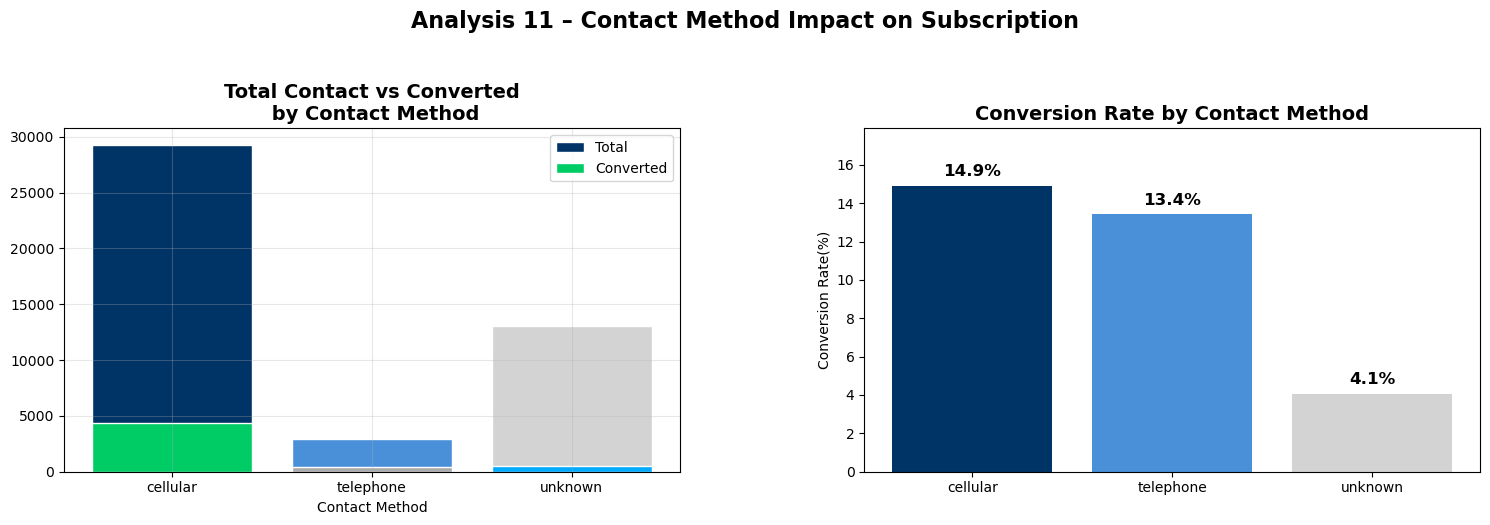

**Poutcome Distribution :**

The dominant contact category : cellular with (29,285 contacts) | Conversion Rate : 14.9%
Telephone category : Telephone with (2,906 contacts) | Conversion Rate : 13.4%


**INSIGHT : Customers contacted via cellular respond at much higher rates than those contacted by other category of contact.**

→ Increase investment in mobile/cellular channels to improve campaign performance.


In [124]:
# _______Q11. Contact Method Analysis____________________________________________________________
contact_category = data.groupby('contact')['term_deposit'].value_counts().unstack(fill_value=0)
contact_category = contact_category.assign(total=contact_category.sum(axis=1))
contact_category = contact_category.assign(success_rate=(100 * contact_category['yes']/contact_category['total']))
display_md("**Contact Conversion TABLE :**")
print(contact_category.sort_values(by='success_rate', ascending=False))

# visualization
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))
# --------------------Left: customer volume per contact----------------------
contact_volume = contact_category.sort_values(by='total', ascending=True)
color_bar = {'cellular':'#003366', 'telephone':'#4a90d9', 'unknown':'lightgray'}
colors = [color_bar.get(o, '#00aaff') for o in contact_category.index]

# bar plot : total contacted
ax[0].bar(contact_category.index, contact_category['total'], color=colors, edgecolor='white', label='Total')

# bar plot : converted
ax[0].bar(contact_category.index, contact_category['yes'], edgecolor='white', color=['#00cc66', '#aaaaaa', '#00aaff'], label='Converted')

ax[0].set_title('Total Contact vs Converted\n by Contact Method',fontsize=14, fontweight='bold')
ax[0].set_xlabel("Contact Method")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# ------------------Right: converion rate per contact-------------------------
contact_success = contact_category.sort_values(by='success_rate', ascending=True)

ax[1].bar(contact_category.index, contact_category['success_rate'],color=colors)

# Annotate bars
for j, rates in enumerate(contact_category['success_rate']):
    ax[1].text(j, rates+0.5, f"{rates:.1f}%", ha='center', fontsize=12, fontweight='bold')

ax[1].set_title("Conversion Rate by Contact Method", fontsize=14, fontweight='bold')
ax[1].set_ylabel("Conversion Rate(%)")
ax[1].set_ylim(0, (contact_success['success_rate'].max() * 1.2))

fig.suptitle('Analysis 11 – Contact Method Impact on Subscription', fontsize=16, fontweight='bold', y=1.04)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

cellular_rate = contact_category.loc[contact_category.index=='cellular', 'success_rate'].values[0]
telephone_rate = contact_category.loc[contact_category.index=='telephone', 'success_rate'].values[0]
telephone_count = contact_category.loc[contact_category.index=='telephone', 'total'].values[0]
display_md("**Poutcome Distribution :**")
print(f"The dominant contact category : {contact_category['success_rate'].idxmax()} with ({contact_category['total'].max():,} contacts) | Conversion Rate : {contact_category['success_rate'].max():.1f}%")
print(f"Telephone category : Telephone with ({telephone_count:,} contacts) | Conversion Rate : {telephone_rate:.1f}%")
display_md("**INSIGHT : Customers contacted via cellular respond at much higher rates than those contacted by other category of contact.**")
print("→ Increase investment in mobile/cellular channels to improve campaign performance.")



---
## **Return On Investment (ROI)**

In [27]:
# compute business impact metrics
display_md("**BUSINESS IMPACT ANALYSIS**")
print("=" * 40)

total_clients = len(data)
successful_subscriptions = (data['term_deposit'] == 'yes').sum()
failed_attempts = (data['term_deposit'] == 'no').sum()
subscription_rate = successful_subscriptions / total_clients *100

print(f"Campaign Overview:")
print(f"   Total clients contacted: {total_clients:,}")
print(f"   Successful subscriptions: {successful_subscriptions:,}")
print(f"   Unsuccessful attempts: {failed_attempts:,}")
print(f"   Success rate: {subscription_rate:.2f}%")

# Calculate efficiency metrics
total_contacts_made = data['campaign'].sum()
avg_contacts_per_client = data['campaign'].mean()
avg_contacts_per_success = data[data['term_deposit'] == 'yes']['campaign'].mean()

print(f"\n Contact Efficiency:")
print(f"   Total contacts made: {total_contacts_made:,}")
print(f"   Average contacts per client: {avg_contacts_per_client:.1f}")
print(f"   Average contacts per successful subscription: {avg_contacts_per_success:.1f}")

# Cost-benefit analysis (hypothetical values)
print(f"\n Hypothetical Cost-Benefit Analysis:")
cost_per_contact = 5  # Assume $5 per contact
revenue_per_subscription = 1000  # Assume $1000 revenue per subscription

total_cost = total_contacts_made * cost_per_contact
total_revenue = successful_subscriptions * revenue_per_subscription
net_profit = total_revenue - total_cost
roi = (net_profit / total_cost) * 100

print(f"   Estimated total cost: ${total_cost:,}")
print(f"   Estimated total revenue: ${total_revenue:,}")
print(f"   Estimated net profit: ${net_profit:,}")
print(f"   Return on Investment (ROI): {roi:.1f}%")


**BUSINESS IMPACT ANALYSIS**

Campaign Overview:
   Total clients contacted: 45,211
   Successful subscriptions: 5,289
   Unsuccessful attempts: 39,922
   Success rate: 11.70%

 Contact Efficiency:
   Total contacts made: 124,956
   Average contacts per client: 2.8
   Average contacts per successful subscription: 2.1

 Hypothetical Cost-Benefit Analysis:
   Estimated total cost: $624,780
   Estimated total revenue: $5,289,000
   Estimated net profit: $4,664,220
   Return on Investment (ROI): 746.5%


## **6. Correlation Analysis & Likelihood of a client subscribing**

In [133]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'term_deposit', 'term_deposit_numeric',
       'age_group', 'balance_category', 'duration_category',
       'contact_frequency_category', 'pdays_category', 'previous_category',
       'year', 'month_numeric', 'year_month', 'age_band', 'age_basket',
       'balance_basket', 'month_order', 'duration_band', 'duration_mins',
       'duration_bucket', 'campaign_capped'],
      dtype='object')

In [134]:
# convert target feature to numeric for correaltion analysis
df_corr = data[['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome','age_basket', 'balance_basket',
       'duration_bucket','contact_frequency_category', 'pdays_category',
       'previous_category', 'year', 'month_numeric', 'year_month']]       # not including datetime features: 'year', 'month_numeric', 'year_month'
       
df_corr['term_deposit_numeric'] = (data['term_deposit'] == 'yes').astype(int)

display_md("**Data Preparation for Correlation Analysis :**")
display_md("**Target Feature Conversion : yes=1, no=0**")
display_md(f"**Subscription Rate :** {df_corr['term_deposit_numeric'].mean():.3f}")


**Data Preparation for Correlation Analysis :**

**Target Feature Conversion : yes=1, no=0**

**Subscription Rate :** 0.117

In [135]:
display(df_corr.value_counts()[:10])

age  job         marital   education  default  balance  housing  loan  contact   day  month  duration  campaign  pdays  previous  poutcome  age_basket  balance_basket   duration_bucket  contact_frequency_category  pdays_category                 previous_category      year  month_numeric  year_month  term_deposit_numeric
19   student     single    primary    no       0        no       no    cellular  4    may    72        4         -1     0         unknown   18-24       Negative         1-3 mins         3-5 Contacts                Never Contacted                No Previous Contact    2009  5              2009-05-01  0                       1
45   management  married   tertiary   no       0        no       yes   cellular  15   jul    112       4         -1     0         unknown   35-49       Negative         1-3 mins         3-5 Contacts                Never Contacted                No Previous Contact    2008  7              2008-07-01  0                       1
                 divorce

In [136]:
# First, let's check what features actually exist in DataFrame
display_md("**Available features in the dataset :**")
print(df_corr.columns.tolist())
print(f"\nDataFrame shape: {df_corr.shape}")

**Available features in the dataset :**

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'age_basket', 'balance_basket', 'duration_bucket', 'contact_frequency_category', 'pdays_category', 'previous_category', 'year', 'month_numeric', 'year_month', 'term_deposit_numeric']

DataFrame shape: (45211, 26)


In [137]:
# Fix the correlation analysis by fixing which features exist
# Define potential numeric feaures(common in banking sectors)
primary_numeric_cols = [
    'age', 'duration', 'campaign', 'pdays', 'previous',
    'emp_var_rate', 'cons_price_idx',
    'cons_conf_idx', 'euribor3m', 'nr_employed', 'term_deposit_numeric',
    # Alternative feature names that might exist
    'emp.var,rate', 'cons.price.idx',
    'cons.conf.idx', 'euribor3m', 'nr.employed', 
    'y', 'term_deposit', 'target'
]

# Check which numeric features belongs to df_corr dataframe
existing_numeric_cols = []
for col in primary_numeric_cols:
    if col in df_corr.columns:
        existing_numeric_cols.append(col)
display_md("**Existing Numeric Features :**")
print(existing_numeric_cols, end="\n")

# Also check for numeric features by data type
numeric_features = df_corr.select_dtypes(include='number').columns.tolist()
display_md("**All Numeric Features in Dataset :**")
print(numeric_features)


**Existing Numeric Features :**

['age', 'duration', 'campaign', 'pdays', 'previous', 'term_deposit_numeric']


**All Numeric Features in Dataset :**

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'year', 'month_numeric', 'term_deposit_numeric']


In [145]:
# Correlation Analysis : use only those columns which actually exist
final_numeric_cols = [col for col in numeric_features if col in df_corr.columns]

# compute correlation matrix with existing features
corr_matrix = df_corr[final_numeric_cols].corr()

# Determine target variable (could be 'term_deposit_numeric', 'term_deposit', or 'y')
target_col = None
for possible_target in ['term_deposit_numeric', 'term_deposit', 'y']:
    if possible_target in corr_matrix.columns:
        target_col = possible_target 
        break

if target_col:
    # concentrate on correlation with target feature
    target_corr = corr_matrix[target_col].drop(target_col).sort_values(key=abs, ascending=False)

    display_md("**CORRELATION WITH TERM DEPOSIT SUBSCRIPTION**")
    print("="*60)
    print(f"{'Features':<16} | {'Correlation':>15} | {'Strength':>11}")
    print("-"*60)

    for col, corr in target_corr.items():
        if abs(corr) >= 0.3:
            strength = 'Strong'
        elif abs(corr) >= 0.1:
            strength = 'Moderate'
        elif abs(corr) >= 0.05:
            stength = 'Weak'
        else:
            strength = 'Very Weak'

        direction = 'Positive' if corr > 0 else 'Negative'
        print(f"{col:<16} | {corr:>15.3f} | {strength} {direction}")

else:
    display_md("**Target feature not found. Please check your target feature name.**")

display_md(f"**INSIGHT : {target_corr.index[0].capitalize()} has the strongest correlation with term deposit subscription.**")
print(' Number of contacts (campaign) has a slight NEGATIVE correlation – more contacts = lower conversion.')


**CORRELATION WITH TERM DEPOSIT SUBSCRIPTION**

Features         |     Correlation |    Strength
------------------------------------------------------------
duration         |           0.395 | Strong Positive
year             |           0.330 | Strong Positive
pdays            |           0.104 | Moderate Positive
previous         |           0.093 | Moderate Positive
campaign         |          -0.073 | Moderate Negative
balance          |           0.053 | Moderate Positive
day              |          -0.028 | Very Weak Negative
age              |           0.025 | Very Weak Positive
month_numeric    |           0.019 | Very Weak Positive


**INSIGHT : Duration has the strongest correlation with term deposit subscription.**

 Number of contacts (campaign) has a slight NEGATIVE correlation – more contacts = lower conversion.


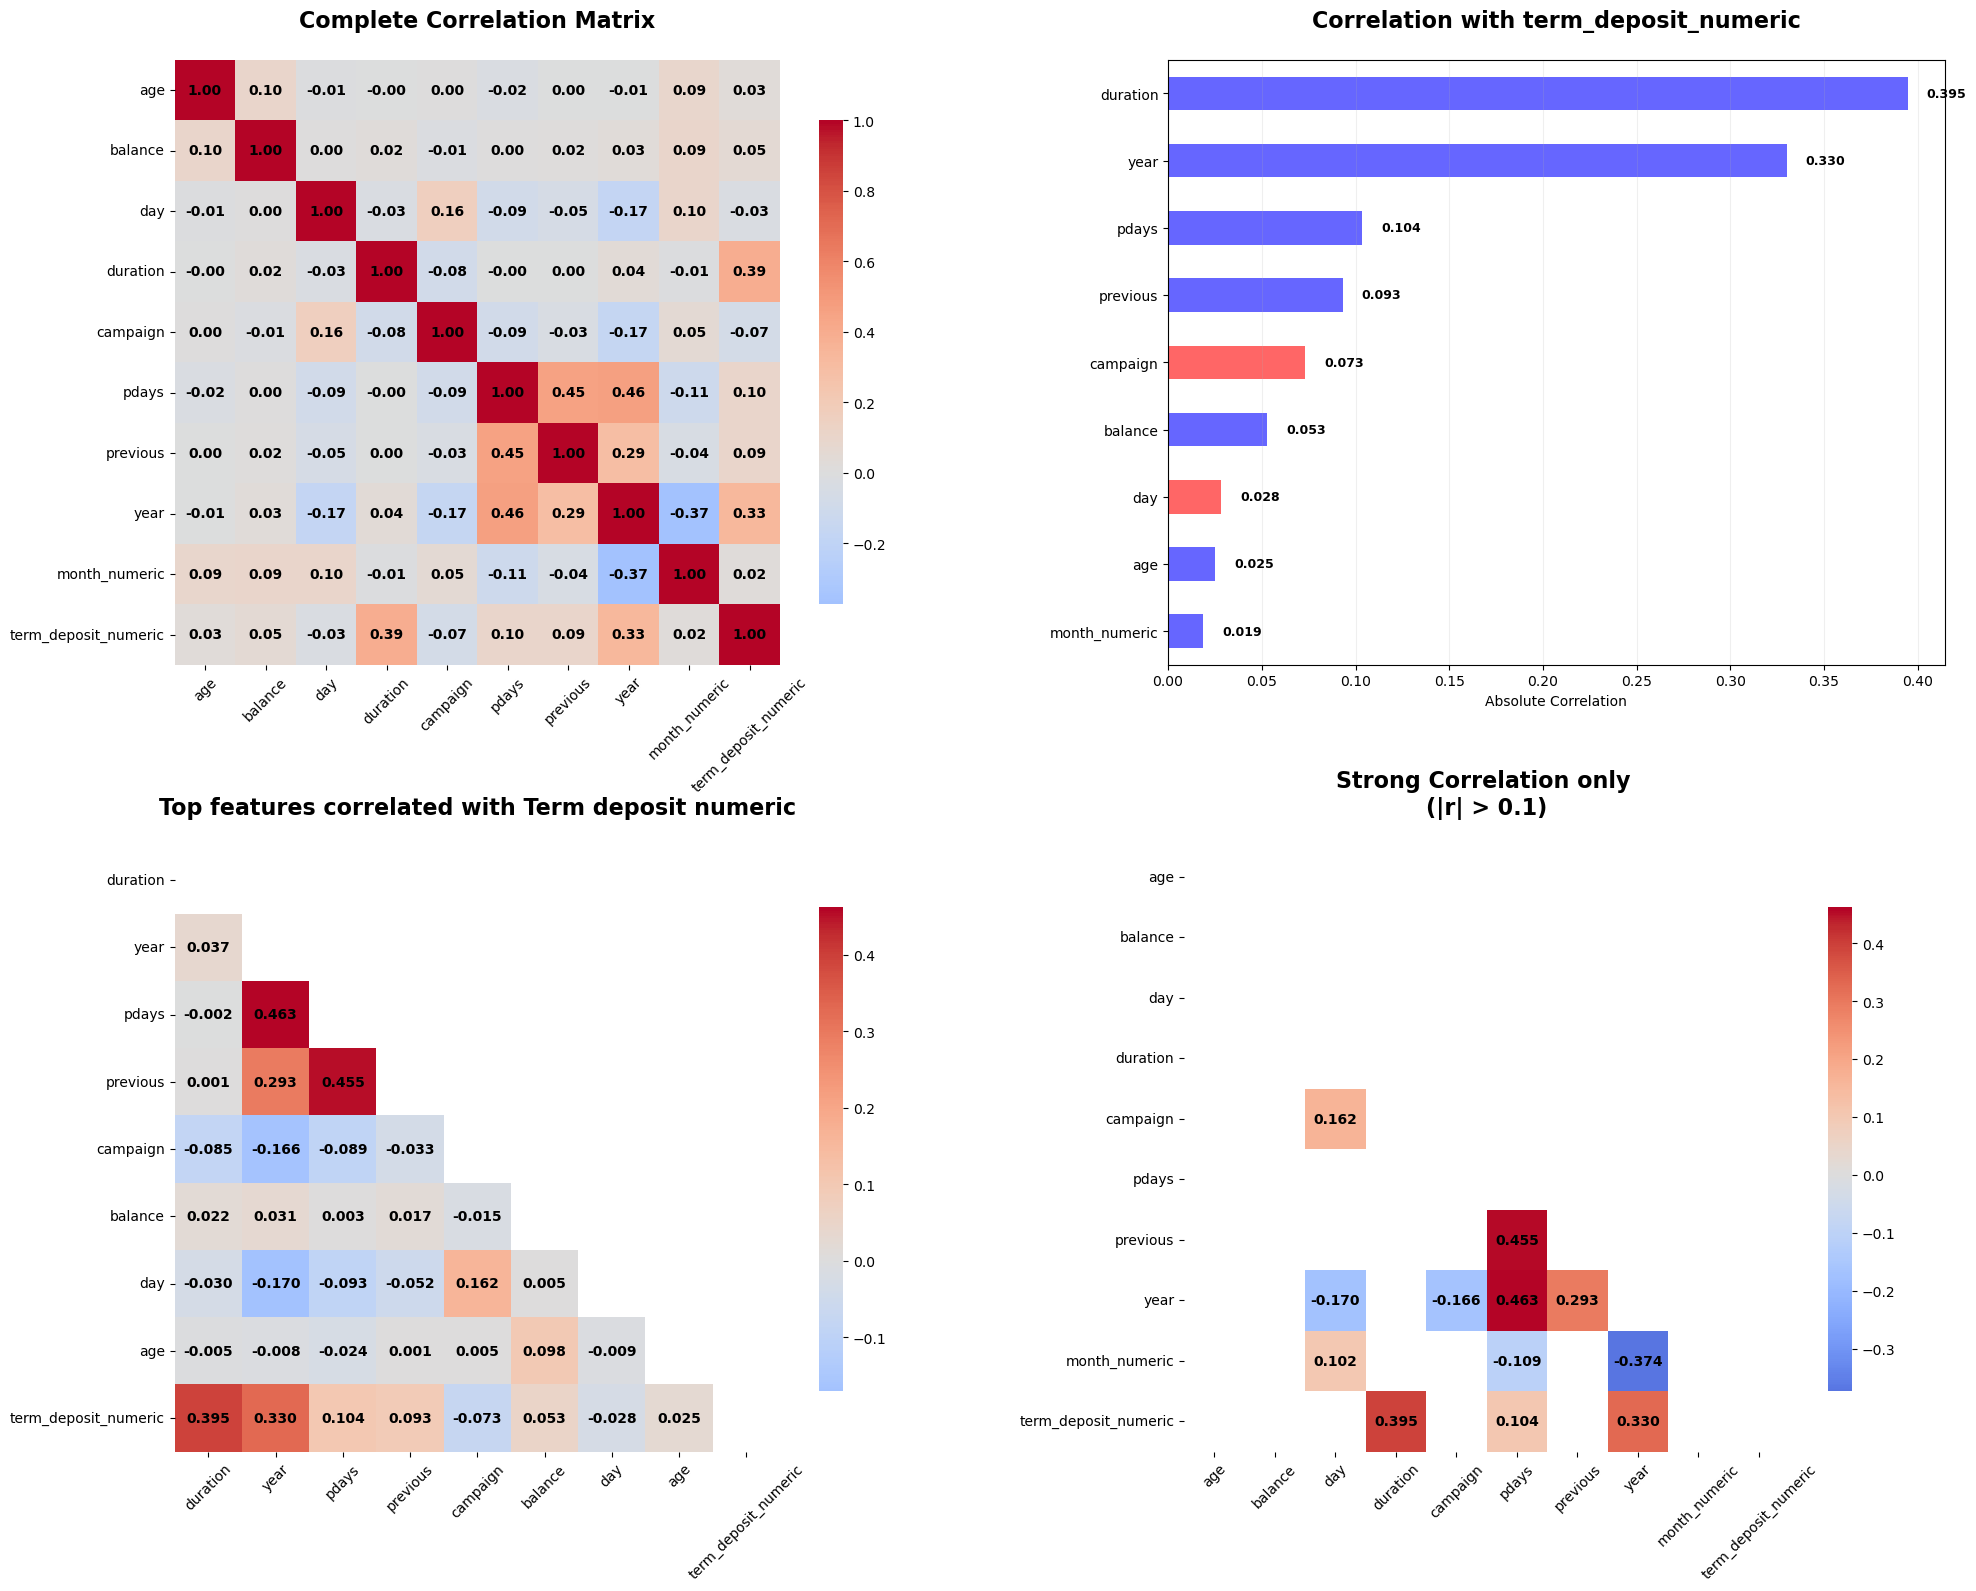

In [139]:
# Create comprehensive correlation matrix visualization
fig, ax = plt.subplots(2, 2, figsize=(20, 16))
ax = ax.flatten()

# 1. Complete correlation matrix heatmap
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', 
    center=0, square=True,
    annot_kws={'fontweight':'bold', 'color':'k'},
    cbar_kws={'shrink':0.8},
    ax=ax[0]
)
ax[0].set_title("Complete Correlation Matrix", fontsize=16, fontweight='bold', y=1.04)
ax[0].tick_params(axis='x', rotation=45)

# 2. bar plot of target feature correlation
if target_col:
    target_correlation = corr_matrix[target_col].drop(target_col)
    target_corr_abs = target_correlation.abs().sort_values(ascending=True)
    colors = ['red' if x < 0 else 'blue' for x in target_correlation[target_corr_abs.index]]

    target_corr_abs.plot(kind='barh', color=colors, ax=ax[1], alpha=0.6)
    ax[1].set_title(f"Correlation with {target_col}", fontsize=16, fontweight='bold', y=1.04)
    ax[1].set_xlabel("Absolute Correlation")
    ax[1].grid(axis='x', alpha=0.2)

    # Label the bar with correlation values
    for index, (column, corr_values) in enumerate(target_corr_abs.items()):
        ax[1].text(abs(corr_values) + 0.01, index, f"{corr_values:.3f}", va='center', fontsize=9, fontweight='bold')

# 3. Top correlated features with target feature
if target_col:
    top_corr_cols = target_correlation.abs().nlargest(8).index.tolist() + [target_col]
    top_corr = corr_matrix.loc[top_corr_cols, top_corr_cols]

    # Create mask for upper triangular matrix
    mask = np.triu(np.ones_like(top_corr, dtype=bool))

    sns.heatmap(top_corr,
                mask=mask,
                annot=True, fmt='.3f',
                cmap='coolwarm',
                center=0, square=True,
                annot_kws={'fontweight':'bold', 'color':'k'},
                cbar_kws={'shrink':0.8},
                ax=ax[2])
    ax[2].set_title(f"Top features correlated with {target_col.replace("_", " ").replace(".", " ").capitalize()}", fontsize=16, fontweight='bold', y=1.04)
    ax[2].tick_params(axis='x', rotation=45)

    # 4. Strong Correlation Only (|Correlation| > 0.1)
    strong_corr_mask = np.abs(corr_matrix) > 0.1
    strong_corr = corr_matrix.where(strong_corr_mask)
    mask = np.triu(np.ones_like(strong_corr, dtype=bool))
    sns.heatmap(
        strong_corr,
        mask=mask,
        annot=True, fmt='.3f',
        cmap='coolwarm',
        center=0, square=True,
        annot_kws={'fontweight':'bold', 'color':'k'},
        cbar_kws={'shrink':0.8},
        ax=ax[3]
    )
    ax[3].set_title("Strong Correlation only \n(|r| > 0.1)", fontsize=16, fontweight='bold', y=1.04)
    ax[3].tick_params(axis='x', rotation=45)
    

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


Target column: term_deposit_numeric
Target column type: int32
Unique values in target: [0 1]


**Campaign Contact Analysis :**

,campaign,count,mean
0,1,17544,0.15
1,2,12505,0.11
2,3,5521,0.11
3,4,3522,0.09
4,5,1764,0.08
5,6,1291,0.07
6,7,735,0.06
7,8,540,0.06
8,9,327,0.06
9,10,266,0.05


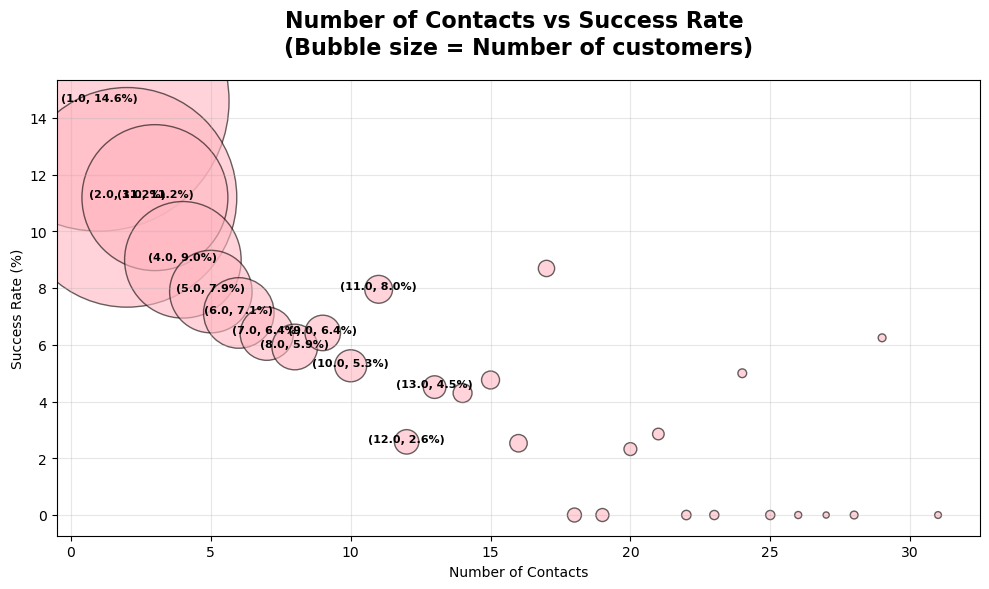

In [35]:
# Handle both string and numeric target features

#  Campaign contacts vs success
if 'campaign' in df_corr.columns and target_col:
    print(f"Target column: {target_col}")
    print(f"Target column type: {df_corr[target_col].dtype}")
    print(f"Unique values in target: {df_corr[target_col].unique()}")
    
    # Handle different target feature types
    if df_corr[target_col].dtype == 'object':  # String values like 'yes'/'no'
        # Convert to numeric for aggregation
        df_corr['target_numeric'] = (df_corr[target_col] == 'yes').astype(int)
        target_for_agg = 'target_numeric'
    else:  # Already numeric
        target_for_agg = target_col
    
    # Now perform the aggregation
    campaign_data = df_corr.groupby('campaign')[target_for_agg].agg(['count', 'mean']).reset_index()
    campaign_data = campaign_data[campaign_data['count'] >= 10]  # Filter for meaningful sample sizes
    
    display_md("**Campaign Contact Analysis :**")
    display(campaign_data.head(10))

    # Create the scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(campaign_data['campaign'], campaign_data['mean'] * 100, 
               s=campaign_data['count']*2, alpha=0.6, c='lightpink', edgecolors='black')
    plt.xlabel('Number of Contacts')
    plt.ylabel('Success Rate (%)')
    plt.title('Number of Contacts vs Success Rate \n(Bubble size = Number of customers)', fontsize=16, fontweight='bold', y=1.04)
    plt.grid(True, alpha=0.3)

    # Add annotation to bubbles
    for idx, row in campaign_data.iterrows():
        # highlight high success rate and high volume
        if row['mean'] > 0.5 or row['count'] > 100:
            plt.text(row['campaign'], row['mean']*100, 
                     f"({row['campaign']}, {row['mean']*100:.1f}%)",
                     fontsize=8, ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    

In [36]:
# First, let's properly identify and prepare the target variable
display_md("**TARGET FEATURE PREPARATION**")
print("=" * 40)

# Check what target columns exist
possible_targets = ['y', 'y_numeric', 'term_deposit', 'term_deposit_numeric']
target_col = None

for col in possible_targets:
    if col in df_corr.columns:
        target_col = col
        print(f"Found target column: {col}")
        print(f"Data type: {df_corr[col].dtype}")
        print(f"Unique values: {df_corr[col].unique()}")
        break

if target_col is None:
    print("Available columns:", df_corr.columns.tolist())
    print("Please specify your target column name")
else:
    # Create a numeric version of target for analysis
    if df_corr[target_col].dtype == 'object':
        if 'yes' in df_corr[target_col].values:
            df_corr['target_numeric'] = (df_corr[target_col] == 'yes').astype(int)
        elif 'True' in df_corr[target_col].values:
            df_corr['target_numeric'] = (df_corr[target_col] == 'True').astype(int)
        else:
            # Try to convert to numeric
            df_corr['target_numeric'] = pd.to_numeric(df_corr[target_col], errors='coerce')
    else:
        df_corr['target_numeric'] = df_corr[target_col]
    
    # MARKETING CAMPAIGN OUTCOMES ANALYSIS
    print()
    display_md("**MARKETING CAMPAIGN OUTCOMES ANALYSIS**")
    print("=" * 50)
    
    # 1. Overall Success Rate
    success_rate = df_corr['target_numeric'].mean() * 100
    total_success = df_corr['target_numeric'].sum()
    total_campaigns = len(df_corr)
    
    print(f"Overall Success Rate: {success_rate:.2f}%")
    print(f"Successful Campaigns: {total_success:,}")
    print(f"Total Campaigns: {total_campaigns:,}")
    print(f"Failed Campaigns: {total_campaigns - total_success:,}")
    
    # 2. Previous Campaign Impact
    if 'poutcome' in df_corr.columns:
        print(f"\nPREVIOUS CAMPAIGN OUTCOMES:")
        prev_outcomes = df_corr['poutcome'].value_counts()
        for outcome, count in prev_outcomes.items():
            pct = (count / len(df_corr)) * 100
            print(f"  {outcome}: {count:,} ({pct:.1f}%)")
        
        # Success rate by previous outcome
        print(f"\nSUCCESS RATE BY PREVIOUS CAMPAIGN:")
        prev_success = df_corr.groupby('poutcome')['target_numeric'].mean() * 100
        for outcome, rate in prev_success.sort_values(ascending=False).items():
            print(f"  {outcome}: {rate:.2f}%")
    
    # 3. Campaign Contact Analysis - FIXED
    if 'campaign' in df_corr.columns:
        print(f"\nCAMPAIGN CONTACT ANALYSIS:")
        
        # Basic statistics
        print(f"Average contacts per customer: {df_corr['campaign'].mean():.2f}")
        print(f"Median contacts: {df_corr['campaign'].median():.0f}")
        print(f"Max contacts: {df_corr['campaign'].max()}")
        
        # Success rate by number of contacts - FIXED
        campaign_analysis = df_corr.groupby('campaign').agg({
            'target_numeric': ['count', 'sum', 'mean']
        }).round(3)
        
        # Flatten column names
        campaign_analysis.columns = ['total_customers', 'successful', 'success_rate']
        campaign_analysis = campaign_analysis.reset_index()
        
        # Filter for meaningful sample sizes
        campaign_analysis_filtered = campaign_analysis[campaign_analysis['total_customers'] >= 5]
        
        print(f"\nSUCCESS RATE BY NUMBER OF CONTACTS (min 5 customers):")
        top_performers = campaign_analysis_filtered.nlargest(5, 'success_rate')
        for _, row in top_performers.iterrows():
            print(f"  {row['campaign']} contacts: {row['success_rate']*100:.1f}% "
                  f"({row['successful']:.0f}/{row['total_customers']:.0f})")
    
    # 4. Call Duration Analysis
    if 'duration' in df_corr.columns:
        print(f"\nCALL DURATION ANALYSIS:")
        print(f"Average duration: {df_corr['duration'].mean():.0f} seconds")
        print(f"Median duration: {df_corr['duration'].median():.0f} seconds")
        
        # Duration bins analysis
        df_corr['duration_category'] = pd.cut(df_corr['duration'], 
                                            bins=[0, 120, 300, 600, float('inf')], 
                                            labels=['Very Short (<2min)', 'Short (2-5min)', 
                                                   'Medium (5-10min)', 'Long (>10min)'])
        
        duration_success = df_corr.groupby('duration_category')['target_numeric'].agg(['count', 'mean'])
        print(f"\nSUCCESS RATE BY CALL DURATION:")
        for category, row in duration_success.iterrows():
            print(f"  {category}: {row['mean']*100:.1f}% ({row['count']:,} calls)")
            

**TARGET FEATURE PREPARATION**

Found target column: term_deposit
Data type: object
Unique values: ['no' 'yes']



**MARKETING CAMPAIGN OUTCOMES ANALYSIS**

Overall Success Rate: 11.70%
Successful Campaigns: 5,289
Total Campaigns: 45,211
Failed Campaigns: 39,922

PREVIOUS CAMPAIGN OUTCOMES:
  unknown: 36,959 (81.7%)
  failure: 4,901 (10.8%)
  other: 1,840 (4.1%)
  success: 1,511 (3.3%)

SUCCESS RATE BY PREVIOUS CAMPAIGN:
  success: 64.73%
  other: 16.68%
  failure: 12.61%
  unknown: 9.16%

CAMPAIGN CONTACT ANALYSIS:
Average contacts per customer: 2.76
Median contacts: 2
Max contacts: 63

SUCCESS RATE BY NUMBER OF CONTACTS (min 5 customers):
  1.0 contacts: 14.6% (2561/17544)
  2.0 contacts: 11.2% (1401/12505)
  3.0 contacts: 11.2% (618/5521)
  32.0 contacts: 11.1% (1/9)
  4.0 contacts: 9.0% (317/3522)

CALL DURATION ANALYSIS:
Average duration: 258 seconds
Median duration: 180 seconds

SUCCESS RATE BY CALL DURATION:
  Very Short (<2min): 1.5% (14,041.0 calls)
  Short (2-5min): 8.6% (18,893.0 calls)
  Medium (5-10min): 19.2% (8,484.0 calls)
  Long (>10min): 48.4% (3,790.0 calls)


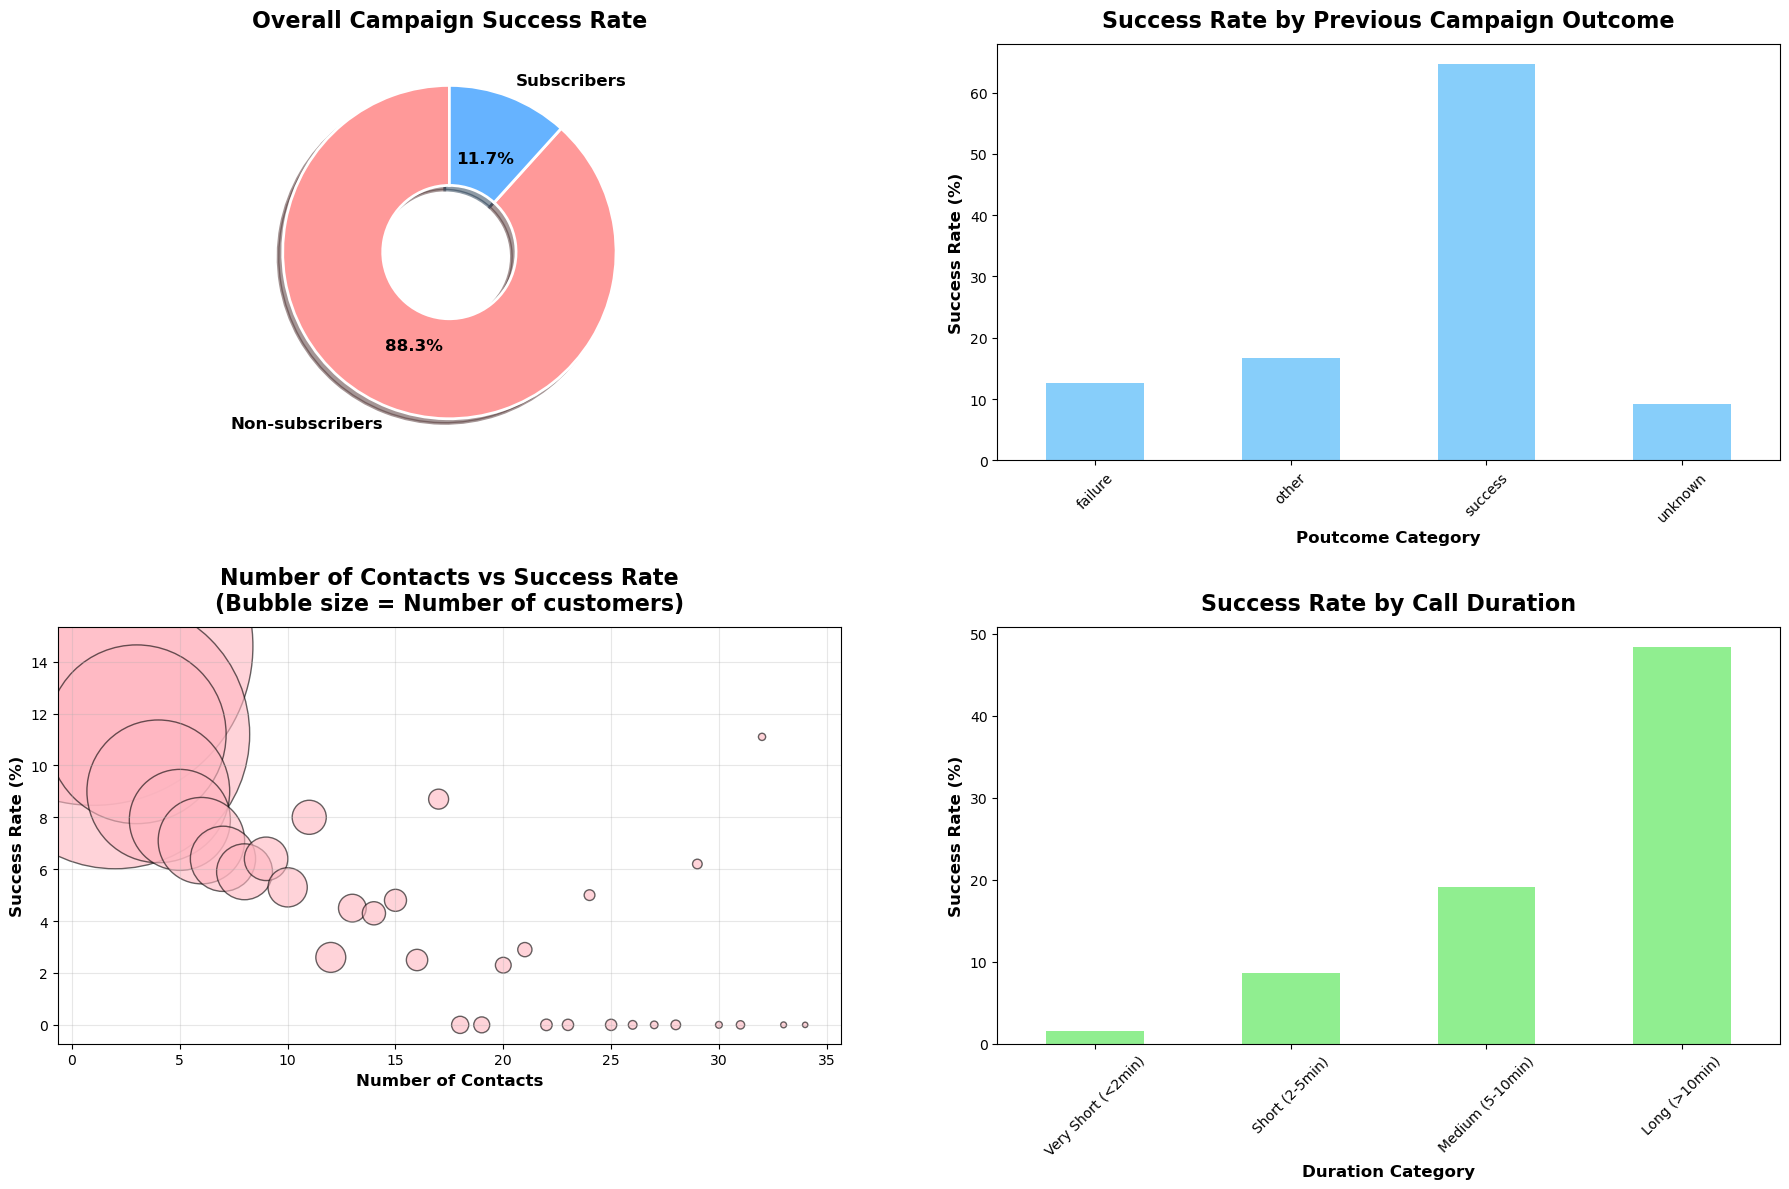

**KEY INSIGHTS FROM MARKETING CAMPAIGNS :**

1. Overall campaign success rate: 11.7% from 45K+ contacts (5,289 customers converted).
2. Best previous campaign outcome: success (64.7% success)
3. Optimal number of contacts: 1 (14.6% success)
4. Most effective call duration: Long (>10min) (0.5% success)


In [37]:
# Create visualizations 
fig, ax = plt.subplots(2, 2, figsize=(18, 12))
ax=ax.flatten()

# 1. Overall Success Rate Pie Chart
success_counts = df_corr['target_numeric'].value_counts()
ax[0].pie(success_counts.values, labels=['Non-subscribers', 'Subscribers'], 
              autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'],
              shadow=True, startangle=90,
              wedgeprops={'width':0.6, 'edgecolor':'white', 'lw':2},
              textprops = {'fontsize':12, 'weight':'bold', 'color':'k'})
ax[0].set_title('Overall Campaign Success Rate', fontsize=16, fontweight='bold', y=1.02)

# 2. Previous Campaign Impact
if 'poutcome' in df_corr.columns:
    prev_impact = df_corr.groupby('poutcome')['target_numeric'].mean() * 100
    prev_impact.plot(kind='bar', ax=ax[1], color='lightskyblue')
    ax[1].set_title('Success Rate by Previous Campaign Outcome', fontsize=16, fontweight='bold', y=1.02)
    ax[1].set_xlabel("Poutcome Category", fontsize=12, fontweight='bold')
    ax[1].set_ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
    ax[1].tick_params(axis='x', rotation=45)

# 3. Campaign Contacts vs Success - FIXED
if 'campaign' in df_corr.columns:
    # Use the fixed campaign_analysis_filtered from above
    ax[2].scatter(campaign_analysis_filtered['campaign'],
                  campaign_analysis_filtered['success_rate'] * 100,
                  s=campaign_analysis_filtered['total_customers']*3, 
                  alpha=0.6, c='lightpink', edgecolors='black')
    ax[2].set_xlabel('Number of Contacts', fontsize=12, fontweight='bold')
    ax[2].set_ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
    ax[2].set_title('Number of Contacts vs Success Rate\n(Bubble size = Number of customers)', fontsize=16, fontweight='bold', y=1.02)
    ax[2].grid(True, alpha=0.3)

# 4. Duration Impact
if 'duration_category' in df_corr.columns:
    duration_impact = df_corr.groupby('duration_category')['target_numeric'].mean() * 100
    duration_impact.plot(kind='bar', color='lightgreen', ax=ax[3])
    ax[3].set_title('Success Rate by Call Duration', fontsize=16, fontweight='bold', y=1.02)
    ax[3].set_ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
    ax[3].set_xlabel("Duration Category", fontsize=12, fontweight='bold')
    ax[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.4)
plt.show()

# Summary insights
display_md("**KEY INSIGHTS FROM MARKETING CAMPAIGNS :**")
print("=" * 55)
print(f"1. Overall campaign success rate: {success_rate:.1f}% from 45K+ contacts (5,289 customers converted).")

if 'poutcome' in df_corr.columns:
    best_prev = prev_success.idxmax()
    best_prev_rate = prev_success.max()
    print(f"2. Best previous campaign outcome: {best_prev} ({best_prev_rate:.1f}% success)")

if 'campaign' in df_corr.columns and len(campaign_analysis_filtered) > 0:
    optimal_contacts = campaign_analysis_filtered.loc[campaign_analysis_filtered['success_rate'].idxmax(), 'campaign']
    optimal_rate = campaign_analysis_filtered['success_rate'].max() * 100
    print(f"3. Optimal number of contacts: {optimal_contacts} ({optimal_rate:.1f}% success)")

if 'duration_category' in df_corr.columns:
    best_duration = duration_success['mean'].idxmax()
    best_duration_rate = duration_success['mean'].max()
    print(f"4. Most effective call duration: {best_duration} ({best_duration_rate:.1f}% success)")
